In [2]:
# import all packages
import numpy as np
import pandas as pd
import glob, os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import math
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm
import geopandas as gpd
# from plot_functions import plot_50states

### Read roadway lengths

In [3]:
folder_path = r'D:\Work\Box Sync\Quantify Infrastructure\Streets_df\All states'

# Get a list of all CSV files in the folder
csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

# Initialize an empty DataFrame to store concatenated data
concatenated_df = pd.DataFrame()

# Loop through each CSV file and concatenate them
for file in csv_files:
    # print(file)
    file_path = os.path.join(folder_path, file)
    
    # Read the CSV file into a DataFrame
    df_state = pd.read_csv(file_path, index_col =0)
    # to check how many places are excluded
    # print(df_state.shape[0])
    # count = count + df_state.shape[0]
    df_state['GEOID'] = df_state['GEOID'].astype(str).str.rjust(7, '0')
    
    # Concatenate the DataFrame to the existing data
    concatenated_df = pd.concat([concatenated_df, df_state], ignore_index=True)
print(concatenated_df.shape)

# 13 missing places due to missing geometry
# Total no of places for 50 states in 2020
# 31249+13 = 31262

(31249, 16)


In [4]:
os.environ['USE_PYGEOS'] = '0'
# Import places map
places_US = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\MapData\all_places\compiled.shp')
print(places_US.shape)

places_50_states = places_US[(places_US['STATEFP'] != '02') & (places_US['STATEFP'] != '60') & (places_US['STATEFP'] != '66') & (places_US['STATEFP'] != '69') & (places_US['STATEFP'] != '72') & (places_US['STATEFP'] != '78')]

print(places_50_states.shape)

(32188, 17)
(31262, 17)


<Axes: >

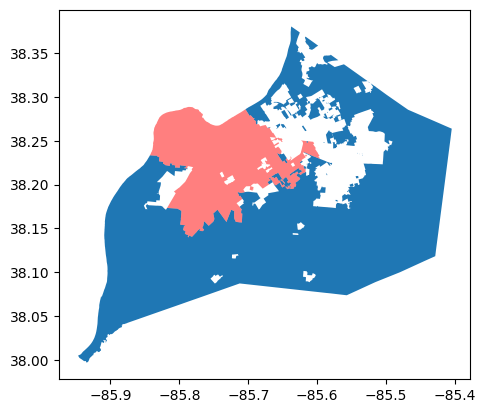

In [5]:
ax = places_50_states[places_50_states['GEOID'] == '2148006'].plot() # 	Louisville/Jefferson County metro government 
places_50_states[places_50_states['GEOID'] == '2148000'].plot(ax=ax, color='red', alpha = 0.5) # 	Louisville city

In [6]:
# concatenated_df.dtypes
concatenated_df.head()

,GEOID,NAMELSAD,motorway,trunk,primary,secondary,tertiary,unclassified,residential,cl_motorway,cl_trunk,cl_primary,cl_secondary,cl_tertiary,cl_unclassified,cl_residential
0,0102260,Ardmore town,0,0,[4982.59329295],[4515.60248183],[3414.7747859],[4679.35177942],[37801.08648814],0,0,[2491.29664647],[2276.2207127],[1707.38739295],[2339.67588971],[18935.83231101]
1,0151264,Mooresville town,[136.16154155],0,0,0,[1221.0092178],0,[4847.4987655],[136.16154155],0,0,0,[610.5046089],0,[2454.80585472]
2,0171496,Somerville town,0,0,0,[16702.05036983],0,0,[42007.38767528],0,0,0,[8351.02518492],0,0,[20623.51394204]
3,0176872,Trinity town,0,[3921.7328301],0,0,[24753.43964382],[3779.4748859],[64473.20671685],0,[3921.7328301],0,0,[12376.71982191],[1889.73744295],[31451.06650643]
4,0130880,Goshen town,0,0,0,0,[12662.95531831],[2292.40449468],[16229.56523005],0,0,0,0,[6331.47765916],[1146.20224734],[8114.78261503]


In [7]:
df = concatenated_df.copy()

In [8]:
# Convert link lengths from str of list elements to float 
def str_to_float(df, column_name):
    return df[column_name].str.replace("[","").str.replace("]","").astype(float)

column_list = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'unclassified', 'residential', 
               'cl_motorway', 'cl_trunk', 'cl_primary', 'cl_secondary', 'cl_tertiary', 'cl_unclassified', 'cl_residential']


for column in column_list:
    df[column] = str_to_float(df, column)

In [9]:
# Calculate total roadway length and total centerline roadway length
roadway_columns = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'unclassified', 'residential']
cl_roadway_columns = ['cl_motorway', 'cl_trunk', 'cl_primary', 'cl_secondary', 'cl_tertiary', 'cl_unclassified', 'cl_residential']

df['total_length'] = df[roadway_columns].sum(axis=1)
df['cl_total_length'] = df[cl_roadway_columns].sum(axis=1)

In [10]:
# NaNs values in roadway length dataframe
df.isna().sum().sum()

0

### Import population and attributes data from depopulation study

In [11]:
df_population = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\forecasted_trend.csv', index_col  = 0)
df_population['GEOID'] = df_population['GEOID'].astype(str).str.rjust(7,'0')

df_attributes = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\df_attributes.csv', index_col  = 0)
df_attributes['GEOID'] = df_attributes['GEOID'].astype(str).str.rjust(7,'0')

df_pop_attr = df_population.merge(df_attributes[['GEOID', 'REGION', 'city type', 'weighted_HU_density_sqmi']], on = 'GEOID')
print(df_population.shape, df_attributes.shape, df_pop_attr.shape)


(31617, 58) (31908, 33) (31616, 61)


In [12]:
# Total population for SSP 2 for each 10 yr interval
print('Total population in millions for 51 states: ===')
df_population[['CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000

Total population in millions for 51 states: ===


CensusPop_20    249.755152
ssp22020        250.994929
ssp22030        271.282551
ssp22040        289.394587
ssp22050        305.168766
ssp22060        320.539073
ssp22070        334.443119
ssp22080        344.689135
ssp22090        350.775132
ssp22100        353.489903
dtype: float64

### Merge roads with population

In [13]:
roads_with_pop_all = df.merge(df_pop_attr[['GEOID', 'State', 'REGION', 'label', 'future trend from SSP 2', 'CensusPop_20', 'city type','weighted_HU_density_sqmi',
                                       'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080',
                                       'ssp22090','ssp22100', 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 
                                                   'ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060',
                                                   'ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']], on = 'GEOID', how='left')
print(roads_with_pop_all.shape)

print(roads_with_pop_all[roads_with_pop_all['GEOID'].str.startswith('214800')][['GEOID', 'NAMELSAD','CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050']])
# 2010 Census
# Louisville/Jefferson County metro government (balance), Kentucky	597337
# 2020 Census
# Louisville city, Kentucky	246161
# Louisville/Jefferson County metro government (balance), Kentucky	386884

# 246161+386884 = 633045

print('Total population in millions for 50 states: ===')
print(roads_with_pop_all[['CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000)

roads_with_pop_all['percentchangeinpop'] = np.abs((roads_with_pop_all['ssp42020'] - roads_with_pop_all['CensusPop_20'])/roads_with_pop_all['CensusPop_20'])
roads_with_pop = roads_with_pop_all[(roads_with_pop_all['percentchangeinpop'] <=.01)]

(31249, 52)
         GEOID                                           NAMELSAD  \
10245  2148006  Louisville/Jefferson County metro government (...   
10405  2148000                                    Louisville city   

       CensusPop_20     ssp22020     ssp22030     ssp22040     ssp22050  
10245      386884.0  389068.4372  424417.2341  456660.9352  485264.1312  
10405           NaN          NaN          NaN          NaN          NaN  
Total population in millions for 50 states: ===
CensusPop_20    248.779899
ssp22020        250.287579
ssp22030        270.511862
ssp22040        288.564911
ssp22050        304.282673
ssp22060        319.590817
ssp22070        333.443879
ssp22080        343.642158
ssp22090        349.691666
ssp22100        352.378215
dtype: float64


### Read redefined urban rural classes

In [14]:
# df_urban_rural_conn = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\buildings_output.csv')
# df_urban_rural_conn = df_urban_rural_conn[['GEOID','citytype_at_2030',  'citytype_at_2040', 'citytype_at_2050', 'citytype_at_2060',
#                                            'citytype_at_2070',  'citytype_at_2080', 'citytype_at_2090', 'citytype_at_2100']]
# df_urban_rural_conn['GEOID'] = df_urban_rural_conn['GEOID'].astype(str).str.rjust(7,'0')

In [15]:
roads_with_pop.columns

Index(['GEOID', 'NAMELSAD', 'motorway', 'trunk', 'primary', 'secondary',
       'tertiary', 'unclassified', 'residential', 'cl_motorway', 'cl_trunk',
       'cl_primary', 'cl_secondary', 'cl_tertiary', 'cl_unclassified',
       'cl_residential', 'total_length', 'cl_total_length', 'State', 'REGION',
       'label', 'future trend from SSP 2', 'CensusPop_20', 'city type',
       'weighted_HU_density_sqmi', 'ssp22020', 'ssp22030', 'ssp22040',
       'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
       'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060', 'ssp12070',
       'ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040',
       'ssp42050', 'ssp42060', 'ssp42070', 'ssp42080', 'ssp42090', 'ssp42100',
       'percentchangeinpop'],
      dtype='object')

### Model comparision Pruned Nonpruned F_test

In [16]:
roads_with_pop['per_cap_mass_at_2020'] =  roads_with_pop['cl_total_length'] / roads_with_pop['CensusPop_20']

stocks_with_pop = roads_with_pop[roads_with_pop['CensusPop_20'] != 0]
stocks_with_pop = stocks_with_pop[stocks_with_pop['city type'] == 'suburban']
print(stocks_with_pop.shape)

infra_col ='cl_total_length'
pop_col = 'CensusPop_20'
df = stocks_with_pop.copy()

### ============== PRUNING ============== ###
# Set the threshold to the 90th percentile
threshold_u = df[infra_col].quantile(0.9)
threshold_l = df[infra_col].quantile(0.1)
# Filter the DataFrame to include only points in the top 10%
df_pruned = df[df[infra_col] < threshold_u]
df_pruned = df_pruned[df_pruned[infra_col] > threshold_l]
print(df_pruned.shape)

y = np.log(df[infra_col].astype(float))
x = np.log(df[pop_col].astype(float))

y_pruned = np.log(df_pruned[infra_col].astype(float))
x_pruned = np.log(df_pruned[pop_col].astype(float)) 

m01 = sm.ols("y ~ x", data={"y": y, "x": x}).fit()
print(m01.params)
print("R-squared value" , m01.rsquared)
m02 = sm.ols("y_pruned ~ x_pruned", data={"y_pruned": y_pruned, "x_pruned": x_pruned}).fit()
anova_results= anova_lm(m01, m02)
print(m02.params)
print("R-squared value" , m02.rsquared)
print(anova_results)
print('\n')

if anova_results['Pr(>F)'][1] < 0.005:
    print(f"Since {anova_results['Pr(>F)'][1]} < 0.005, difference is significant")
    print("Built pruned model")


(6885, 54)
(5507, 54)
Intercept    3.924751
x            0.828891
dtype: float64
R-squared value 0.8511531245954935
Intercept    5.147044
x_pruned     0.691241
dtype: float64
R-squared value 0.7203504996785941
   df_resid          ssr  df_diff     ss_diff         F         Pr(>F)
0    6883.0  1794.477208      0.0         NaN       NaN            NaN
1    5505.0  1132.872134   1378.0  661.605073  2.333061  1.380779e-102


Since 1.3807790646000282e-102 < 0.005, difference is significant
Built pruned model


C:\Users\uttar\AppData\Local\Temp\ipykernel_26552\108186394.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roads_with_pop['per_cap_mass_at_2020'] =  roads_with_pop['cl_total_length'] / roads_with_pop['CensusPop_20']


total_area: 374.0667284072186


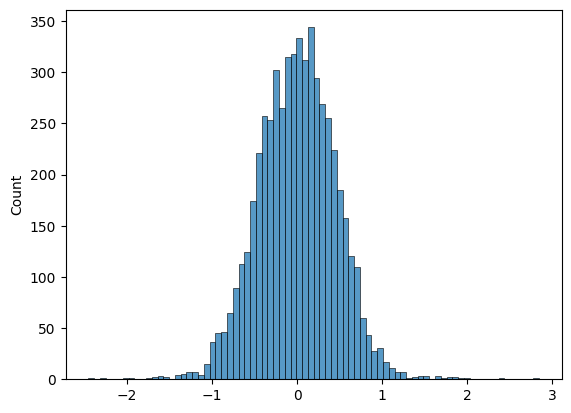

In [17]:
ax = sns.histplot(m02.resid)
values_sns = [h.get_height() for h in ax.patches]
bins_sns = [h.get_width() for h in ax.patches]

# total_area = sum([height * width for height, width in zip(values_sns, bins_sns)])
total_area = np.sum(np.array(bins_sns) * np.array(values_sns)) # shorter, faster using numpy
print("total_area:", total_area)  # 1.0

total_area: 284.5552231803576


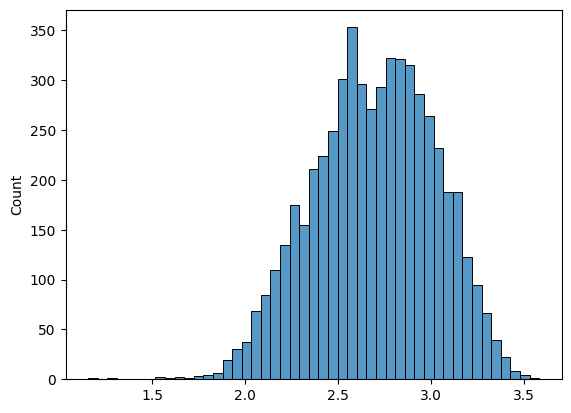

In [18]:
ax = sns.histplot((m02.resid + m02.params.Intercept) - np.log(df_pruned['per_cap_mass_at_2020']))
# Source: https://stackoverflow.com/questions/62569955/calculate-the-area-under-the-histogram-with-seaborn
values_sns = [h.get_height() for h in ax.patches]
bins_sns = [h.get_width() for h in ax.patches]

# total_area = sum([height * width for height, width in zip(values_sns, bins_sns)])
total_area = np.sum(np.array(bins_sns) * np.array(values_sns)) # shorter, faster using numpy
print("total_area:", total_area)  # 1.0

### Fit scale law

In [92]:

# # fit the total population and total infrastructure data in the scaling law 
# def find_scale_parameters(df, infra_col, pop_col):
#     df.loc[:,'log_pop_col'] = np.log(df[pop_col].astype(float))
#     df.loc[:, 'log_infra_col'] = np.log(df[infra_col].astype(float))

#     # To get an interactive plot
#     # fig = px.scatter(df, x='log_pop_col', y='log_infra_col', hover_data=['GEOID', 'NAMELSAD'],
#     #                 width=800, height=800) 
#     # fig.show()

#     sns.regplot(x='log_pop_col', y='log_infra_col', data=df, 
#                 y_jitter=.03, ci =None, scatter_kws={"s": 1})
#     x = df['log_pop_col']
#     y = df['log_infra_col']

#     #run anova model to find confidence intervals
#     # Fit the regression model
#     model = sm.ols("y ~ x", data={"y": y, "x": x}).fit()

#     # Display regression summary
#     print(model.summary())
#     print(model.params)
#     print("R-squared value" , model.rsquared)
#     print('====================================')
#     # Calculate confidence intervals using ANOVA
#     anova_result = anova_lm(model)
#     conf_int = model.conf_int(alpha=0.05, cols=None)

#     # Display ANOVA results and confidence intervals
#     print("\nConfidence Intervals: 'log(a)' and 'b' values---")
#     print(conf_int)
#     intercepts = [conf_int.iloc[0][0], conf_int.iloc[0][1]]
#     beta = [conf_int.iloc[1][0], conf_int.iloc[1][1]]
#     model_params = model.params

#     return intercepts, beta, model_params

In [20]:
# predictions = x[0].get_prediction(df01)
# frame = predictions.summary_frame(alpha=0.05)
# # frame.sort_values(by= 'obs_ci_lower')

In [21]:
# pred_ols = x[0].get_prediction(df01)
# iv_l = pred_ols.summary_frame()["obs_ci_lower"]
# iv_u = pred_ols.summary_frame()["obs_ci_upper"]

# fig, ax = plt.subplots(figsize=(8, 6))

# ax.plot(df01, np.log(df_for_fitting[current_stock_col]), "o", label="data")
# # ax.plot(df01, y_true, "b-", label="True")
# ax.plot(df01, x[0].fittedvalues, "r--.", label="OLS")
# ax.plot(df01, iv_u, "r--")
# ax.plot(df01, iv_l, "r--")
# ax.legend(loc="best")

### Find next stock

In [22]:
pd.set_option('mode.chained_assignment', None) # To stop SettingWithCopy warning
list_of_city_types = ['urban', 'suburban', 'periurban', 'rural']

In [23]:
print('Total NaNs in population and roadway length:===')
print(roads_with_pop[['CensusPop_20', 'ssp22040', 'total_length']].isna().sum())
print("Places with no roadway:===", roads_with_pop[roads_with_pop['cl_total_length'] == 0].shape[0])
print("Places with zero population in census 2020:===", roads_with_pop[roads_with_pop['CensusPop_20'] == 0].shape[0])
print("Places with no available population forecast:===", roads_with_pop[roads_with_pop['ssp22040'].isnull()].shape[0])
print(roads_with_pop.shape)

Total NaNs in population and roadway length:===
CensusPop_20    0
ssp22040        0
total_length    0
dtype: int64
Places with no roadway:=== 0
Places with zero population in census 2020:=== 0
Places with no available population forecast:=== 0
(30573, 54)


In [24]:
roads_clean = roads_with_pop.dropna(subset=['CensusPop_20', 'ssp22040', 'total_length', 'cl_total_length']).reset_index(drop=True)
roads_clean['per_cap_mass_at_2020'] = roads_clean['cl_total_length'] / roads_clean['CensusPop_20'].round(0)
print("Shape of the clean dataset with nonzero values:==")
print(roads_clean.shape)
# roads_clean = roads_clean.merge(df_urban_rural_conn, on ='GEOID')
print("Shape of the clean dataset with newly defined urban rural continuum at each time interval values:==")
print(roads_clean.shape)

Shape of the clean dataset with nonzero values:==
(30573, 54)
Shape of the clean dataset with newly defined urban rural continuum at each time interval values:==
(30573, 54)


### Run loops 

### for 2030

(30573, 15)
Initial dataframe:====
(30573, 15)
Shape of the dataframe for urban:====
(312, 16)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 16)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     2133.
Date:                Thu, 02 May 2024   Prob (F-statistic):          1.98e-132
Time:                        11:48:14   Log-Likelihood:                -200.91
No. Observations:                 280   AIC:                             405.8
Df Residuals:                     278   BIC:                             413.1
Df Model:                           1                                         
Covariance Type:      

Initial dataframe:====
(30573, 16)
Shape of the dataframe for periurban:====
(5698, 16)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(5128, 16)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                 1.280e+04
Date:                Thu, 02 May 2024   Prob (F-statistic):               0.00
Time:                        11:48:37   Log-Likelihood:                -3601.1
No. Observations:                5128   AIC:                             7206.
Df Residuals:                    5126   BIC:                             7219.
Df Model:                           1                                         
Covariance Type:            

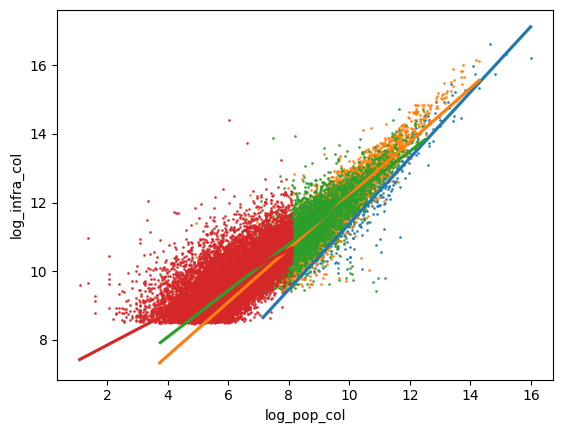

In [26]:
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'D:\Work\Box Sync\Quantify Infrastructure\Scripts\scenarios')
from functions.functions_scaling import find_scale_parameters, find_next_stock, process_stock_at_t


current_stock_col = 'cl_total_length'
current_pop_col = 'CensusPop_20'
next_pop_col = 'ssp22030'
t = 2030

df_for_analysis = roads_clean[['GEOID', 'State', 'NAMELSAD','city type', 'CensusPop_20', 'ssp22020', 'ssp22030', 
                                'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100','cl_total_length']]

#  'citytype_at_2030', 'citytype_at_2040','citytype_at_2050', 'citytype_at_2060', 'citytype_at_2070',  'citytype_at_2080', 'citytype_at_2090', 'citytype_at_2100',

df_for_2030 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2030, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2030, on ='GEOID')
print(roads_clean.shape)

In [31]:
df_for_analysis.rename({'surface_Res_at_2030' : 'cl_length_at_2030'}, axis=1, inplace=True)

### 2040

(30537, 18)
Initial dataframe:====
(30537, 18)
Shape of the dataframe for urban:====
(312, 18)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 18)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     2122.
Date:                Thu, 02 May 2024   Prob (F-statistic):          3.69e-132
Time:                        12:03:49   Log-Likelihood:                -202.06
No. Observations:                 280   AIC:                             408.1
Df Residuals:                     278   BIC:                             415.4
Df Model:                           1                                         
Covariance Type:      

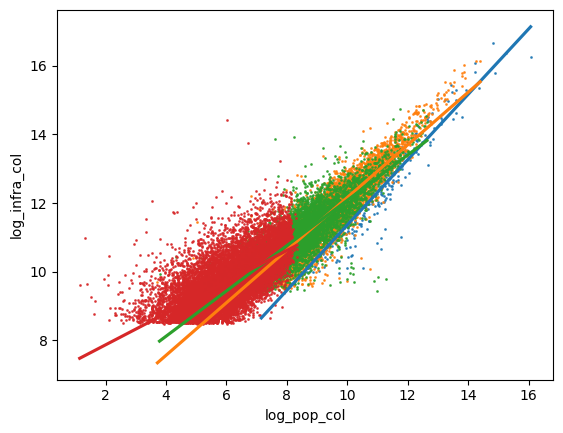

In [32]:
current_stock_col ='cl_length_at_2030'
current_pop_col = 'ssp22030'
next_pop_col = 'ssp22040'
t = 2040

df_for_2040 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2040, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2040, on ='GEOID')
print(roads_clean.shape)

### 2050

(30537, 20)
Initial dataframe:====
(30537, 20)
Shape of the dataframe for urban:====
(312, 20)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 20)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     2107.
Date:                Thu, 02 May 2024   Prob (F-statistic):          9.20e-132
Time:                        12:05:08   Log-Likelihood:                -203.34
No. Observations:                 280   AIC:                             410.7
Df Residuals:                     278   BIC:                             418.0
Df Model:                           1                                         
Covariance Type:      

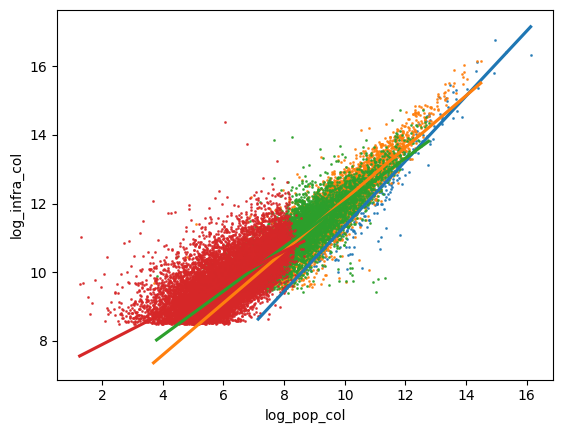

In [33]:
df_for_analysis.rename({'surface_Res_at_2040' : 'cl_length_at_2040'}, axis=1, inplace=True)

current_stock_col ='cl_length_at_2040'
current_pop_col = 'ssp22040'
next_pop_col = 'ssp22050'
t = 2050

df_for_2050 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2050, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2050, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2050' : 'cl_length_at_2050'}, axis=1, inplace=True)

(30537, 22)
Initial dataframe:====
(30537, 22)
Shape of the dataframe for urban:====
(312, 22)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 22)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     2079.
Date:                Thu, 02 May 2024   Prob (F-statistic):          4.57e-131
Time:                        12:06:19   Log-Likelihood:                -205.34
No. Observations:                 280   AIC:                             414.7
Df Residuals:                     278   BIC:                             421.9
Df Model:                           1                                         
Covariance Type:      

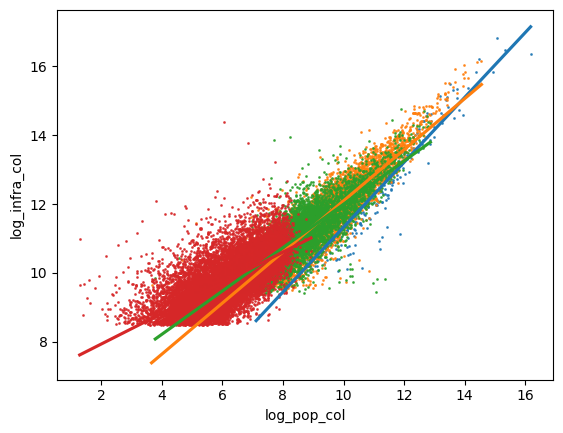

In [34]:
current_stock_col ='cl_length_at_2050'
current_pop_col = 'ssp22050'
next_pop_col = 'ssp22060'
t = 2060

df_for_2060 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2060, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2060, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2060' : 'cl_length_at_2060'}, axis=1, inplace=True)

(30537, 24)
Initial dataframe:====
(30537, 24)
Shape of the dataframe for urban:====
(312, 24)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 24)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.881
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     2054.
Date:                Thu, 02 May 2024   Prob (F-statistic):          2.02e-130
Time:                        12:07:19   Log-Likelihood:                -207.12
No. Observations:                 280   AIC:                             418.2
Df Residuals:                     278   BIC:                             425.5
Df Model:                           1                                         
Covariance Type:      

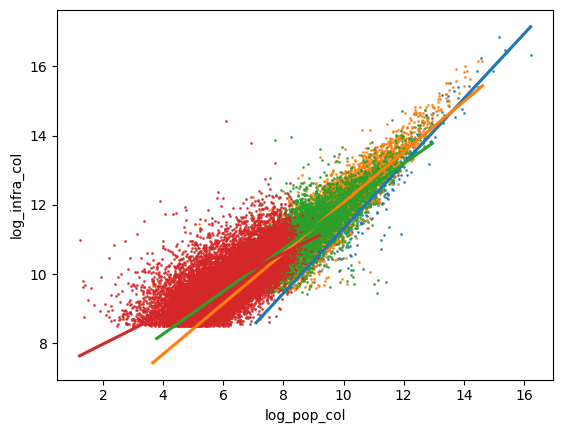

In [35]:
current_stock_col ='cl_length_at_2060'
current_pop_col = 'ssp22060'
next_pop_col = 'ssp22070'
t = 2070

df_for_2070 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2070, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2070, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2070' : 'cl_length_at_2070'}, axis=1, inplace=True)

### 2080-2100

(30537, 26)
Initial dataframe:====
(30537, 26)
Shape of the dataframe for urban:====
(312, 26)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 26)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     2025.
Date:                Thu, 02 May 2024   Prob (F-statistic):          1.20e-129
Time:                        12:08:27   Log-Likelihood:                -209.14
No. Observations:                 280   AIC:                             422.3
Df Residuals:                     278   BIC:                             429.5
Df Model:                           1                                         
Covariance Type:      

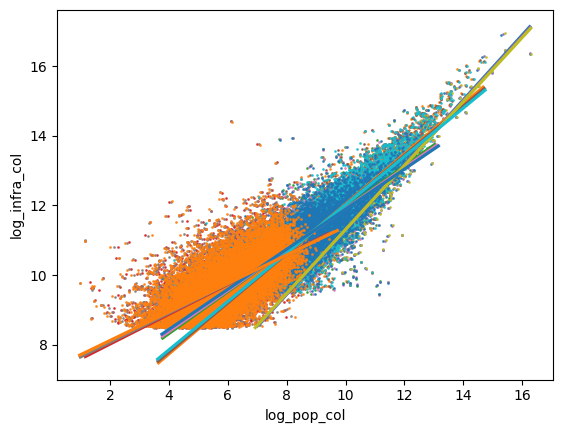

In [36]:
current_stock_col ='cl_length_at_2070'
current_pop_col = 'ssp22070'
next_pop_col = 'ssp22080'
t = 2080

df_for_2080 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2080, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2080, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2080' : 'cl_length_at_2080'}, axis=1, inplace=True)

current_stock_col ='cl_length_at_2080'
current_pop_col = 'ssp22080'
next_pop_col = 'ssp22090'
t = 2090

df_for_2090 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2090, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2090, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2090' : 'cl_length_at_2090'}, axis=1, inplace=True)


current_stock_col ='cl_length_at_2090'
current_pop_col = 'ssp22090'
next_pop_col = 'ssp22100'
t = 2100

df_for_2100 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2100, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2100, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2100' : 'cl_length_at_2100'}, axis=1, inplace=True)


In [37]:
roads_clean[['State', 'NAMELSAD', 'per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050','per_cap_mass_at_2060','per_cap_mass_at_2100']].sort_values(by= 'per_cap_mass_at_2020')

,State,NAMELSAD,per_cap_mass_at_2020,per_cap_mass_at_2030,per_cap_mass_at_2040,per_cap_mass_at_2050,per_cap_mass_at_2060,per_cap_mass_at_2100
17644,36.0,Saltaire village,0.031833,0.030606,0.029822,0.029277,0.028765,0.028282
15219,30.0,Riverview Colony CDP,0.076707,0.073925,0.071336,0.068920,0.064959,0.059054
3069,6.0,Stevenson Ranch CDP,0.225636,0.210893,0.202372,0.198474,0.197276,0.216569
2523,6.0,Hacienda Heights CDP,0.230077,0.212364,0.200454,0.192379,0.186210,0.181562
2747,6.0,Marina del Rey CDP,0.235208,0.229523,0.225542,0.223033,0.221488,0.234062
...,...,...,...,...,...,...,...,...
19505,38.0,Calio city,4310.472237,4172.788843,4068.619003,3993.342619,3906.660022,3488.396916
9258,20.0,Greeley County unified government (balance),4416.076010,4361.859225,4315.435739,4257.341716,4125.646687,3851.816735
14342,29.0,River Bend village,4801.610049,4634.661034,4257.093469,4154.035753,4057.247584,3664.953725
4032,12.0,Bay Lake city,5964.395265,5093.322904,4464.038294,3982.969162,3632.124936,2899.500781


### PLOTS

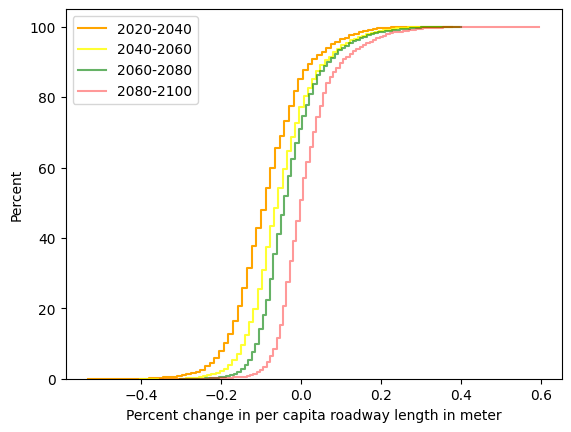

In [38]:
# roads_clean[roads_clean['per_cap_mass_at_2100'] < roads_clean['per_cap_mass_at_2020']]['per_cap_mass_at_2020'].describe()
data = roads_clean[roads_clean['city type'] == 'suburban']

stat_method = 'percent'
cumulative_method = True

sns.histplot(np.sort((data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']), alpha = 1.0, color= 'orange', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
sns.histplot(np.sort((data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])/data['per_cap_mass_at_2040']), alpha = 0.8, color= 'yellow', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
sns.histplot(np.sort((data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']), alpha = 0.6, color ='green', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
sns.histplot(np.sort((data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])/data['per_cap_mass_at_2080']), alpha = 0.4, color ='red', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
plt.xlabel('Percent change in per capita roadway length in meter')
plt.legend(labels=['2020-2040', '2040-2060', '2060-2080', '2080-2100'])

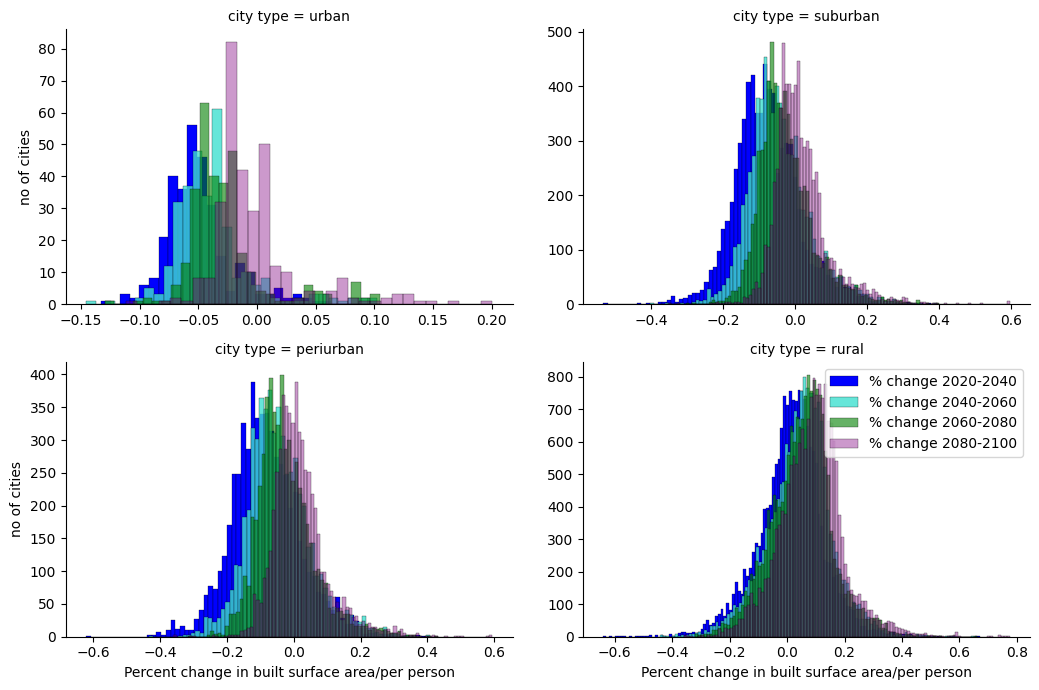

In [39]:
data = roads_clean

data['percent change from 2020-2040'] = (data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']
data['percent change from 2040-2060'] = (data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])/data['per_cap_mass_at_2040']
data['percent change from 2060-2080'] = (data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']
data['percent change from 2080-2100'] = (data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])/data['per_cap_mass_at_2080']

citytype_name = ['urban', 'suburban', 'periurban', 'rural']

# fig, axs = plt.subplots(nrows =2, ncols =2,  figsize=(7, 7))
g = sns.FacetGrid(data, col='city type', col_wrap=2, col_order = ['urban', 'suburban', 'periurban', 'rural'], 
                  sharex=False, sharey=False, margin_titles=False, height=3.5, aspect=1.5)
g.map(sns.histplot,'percent change from 2020-2040', alpha = 1.0, color= 'blue', linewidth=0.2)
g.map(sns.histplot,'percent change from 2040-2060', alpha = 0.8, color= 'Turquoise', linewidth=0.2)
g.map(sns.histplot,'percent change from 2060-2080', alpha = 0.6, color= 'green', linewidth=0.2)
g.map(sns.histplot,'percent change from 2080-2100', alpha = 0.4, color= 'purple', linewidth=0.2)
g.set_axis_labels("Percent change in built surface area/per person", "no of cities")
plt.legend(labels=['% change 2020-2040', '% change 2040-2060', '% change 2060-2080', '% change 2080-2100'])

In [40]:
# # import matplotlib
# # matplotlib.rcParams.update(matplotlib.rcParamsDefault)

# citytype_name = ['urban', 'suburban', 'periurban', 'rural']

# # fig, axs = plt.subplots(nrows =2, ncols =2,  figsize=(7, 7))
# data = roads_clean
# data['percent change from 2020-2040'] = (data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']
# data['percent change from 2040-2060'] = (data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])/data['per_cap_mass_at_2040']
# data['percent change from 2060-2080'] = (data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']
# data['percent change from 2080-2100'] = (data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])/data['per_cap_mass_at_2080']


# g = sns.FacetGrid(data, col='city type', col_wrap=2, col_order = ['urban', 'suburban', 'periurban', 'rural'], 
#                   sharex=False, sharey=False, margin_titles=False, height=3.5, aspect=1.5)

# g.map(sns.histplot,'percent change from 2020-2040', alpha = 1.0, color= 'Tan', linewidth=0.2, kde=True, fill = False)
# g.map(sns.histplot,'percent change from 2040-2060', alpha = 0.8, color= 'Turquoise', linewidth=0.2, kde=True, fill = False)
# g.map(sns.histplot,'percent change from 2060-2080', alpha = 0.6, color= 'green', linewidth=0.2, kde=True, fill = False)
# g.map(sns.histplot,'percent change from 2080-2100', alpha = 0.4, color= 'purple', linewidth=0.2, kde=True, fill = False)
# g.set_axis_labels("Percent change in roadway length/per person", "no of cities")
# plt.legend(labels=['% change 2020-2040', '% change 2040-2060', '% change 2060-2080', '% change 2080-2100'])

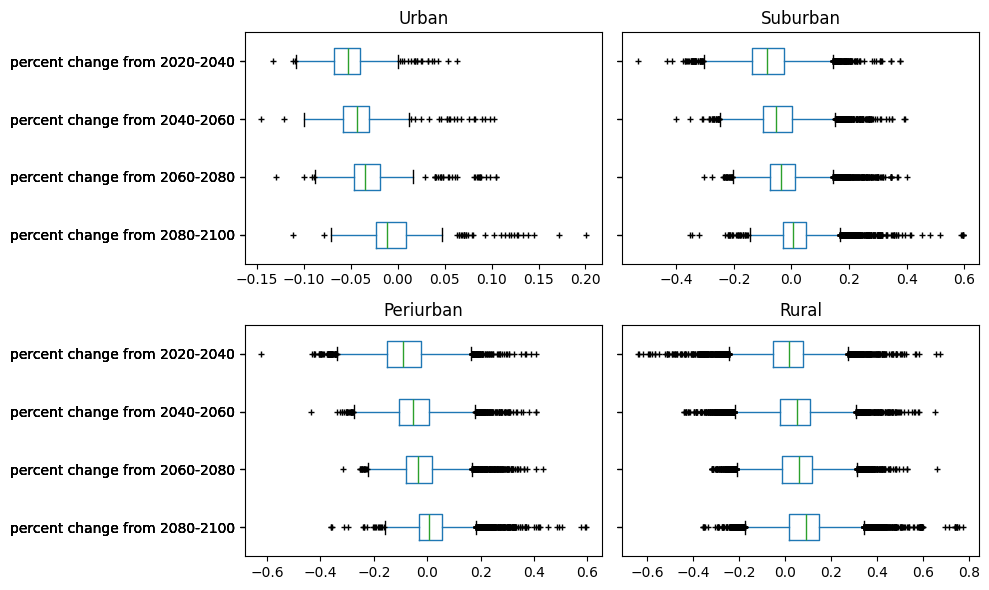

In [41]:
columns_boxplot = ['percent change from 2080-2100', 'percent change from 2060-2080','percent change from 2040-2060','percent change from 2020-2040']

# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey=True)

# Boxplot for Value1 and Value2 in the first subplot
roads_clean[roads_clean['city type'] == 'urban'][columns_boxplot].boxplot(ax=axs[0, 0], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 0].set_title('Urban')
# # Boxplot for Value1 and Value3 in the second subplot
roads_clean[roads_clean['city type'] == 'suburban'][columns_boxplot].boxplot(ax=axs[0, 1], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 1].set_title('Suburban')
# # Boxplot for Value2 and Value3 in the third subplot
roads_clean[roads_clean['city type'] == 'periurban'][columns_boxplot].boxplot(ax=axs[1, 0], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 0].set_title('Periurban')
# # Boxplot for all three values in the fourth subplot
roads_clean[roads_clean['city type'] == 'rural'][columns_boxplot].boxplot(ax=axs[1, 1], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 1].set_title('Rural')
# Adjust layout
plt.tight_layout()

for ax in fig.axes:
    # ax.axis("off")
    ax.grid(False)

### Plot Maps


In [42]:
roads_clean.to_csv(r'D:\Work\Box Sync\Quantify Infrastructure\output_csvs\roads_projected.csv')

In [43]:
import pandas as pd
import os
import geopandas as gpd
import seaborn as sns

roads_df =  pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\output_csvs\roads_projected.csv')
roads_df['GEOID'] = roads_df['GEOID'].astype(str).str.rjust(7,'0')
roads_df['percent change from 2020-2030'] = (roads_df['per_cap_mass_at_2030'] - roads_df['per_cap_mass_at_2020']) / roads_df['per_cap_mass_at_2020']
roads_df['percent change from 2030-2040'] = (roads_df['per_cap_mass_at_2040'] - roads_df['per_cap_mass_at_2030']) / roads_df['per_cap_mass_at_2030']
roads_df['percent change from 2040-2050'] = (roads_df['per_cap_mass_at_2050'] - roads_df['per_cap_mass_at_2040']) / roads_df['per_cap_mass_at_2040']
roads_df['percent change from 2050-2060'] = (roads_df['per_cap_mass_at_2060'] - roads_df['per_cap_mass_at_2050']) / roads_df['per_cap_mass_at_2050']
roads_df['percent change from 2060-2070'] = (roads_df['per_cap_mass_at_2070'] - roads_df['per_cap_mass_at_2060']) / roads_df['per_cap_mass_at_2060']
roads_df['percent change from 2070-2080'] = (roads_df['per_cap_mass_at_2080'] - roads_df['per_cap_mass_at_2070']) / roads_df['per_cap_mass_at_2070']
roads_df['percent change from 2080-2090'] = (roads_df['per_cap_mass_at_2090'] - roads_df['per_cap_mass_at_2080']) / roads_df['per_cap_mass_at_2080']
roads_df['percent change from 2090-2100'] = (roads_df['per_cap_mass_at_2100'] - roads_df['per_cap_mass_at_2090']) / roads_df['per_cap_mass_at_2090']
roads_df['percent change from 2020-2060'] = (roads_df['per_cap_mass_at_2060'] - roads_df['per_cap_mass_at_2020']) / roads_df['per_cap_mass_at_2020']
roads_df['percent change from 2060-2100'] = (roads_df['per_cap_mass_at_2100'] - roads_df['per_cap_mass_at_2060']) / roads_df['per_cap_mass_at_2060']
roads_df['percent change from 2020-2100'] = (roads_df['per_cap_mass_at_2100'] - roads_df['per_cap_mass_at_2020']) / roads_df['per_cap_mass_at_2020']

# Define your thresholds
thresholds = [-1.00, -.50, -.10, 0, 0.25, 0.50, 1.00, 2.05]

# Create labels for each category
labels = ["Pressurized", "Overwhelmed" , "Utilized", 'Low Burden', 'Medium Burden', 'High Burden', 'Highest Burden']

# Use pd.cut() to create the categorical variable
roads_df['Burden index_upto_60'] = pd.cut(roads_df['percent change from 2020-2060'], bins=thresholds, labels=labels)
# Use pd.cut() to create the categorical variable
roads_df['Burden index_upto_100'] = pd.cut(roads_df['percent change from 2020-2060'], bins=thresholds, labels=labels)

In [44]:
roads_df['per cap added from 2020-2030'] = (roads_df['per_cap_mass_at_2030'] - roads_df['per_cap_mass_at_2020'])
roads_df['per cap added from 2030-2040'] = (roads_df['per_cap_mass_at_2040'] - roads_df['per_cap_mass_at_2030'])
roads_df['per cap added from 2040-2050'] = (roads_df['per_cap_mass_at_2050'] - roads_df['per_cap_mass_at_2040'])
roads_df['per cap added from 2050-2060'] = (roads_df['per_cap_mass_at_2060'] - roads_df['per_cap_mass_at_2050'])
roads_df['per cap added from 2060-2070'] = (roads_df['per_cap_mass_at_2070'] - roads_df['per_cap_mass_at_2060'])
roads_df['per cap added from 2070-2080'] = (roads_df['per_cap_mass_at_2080'] - roads_df['per_cap_mass_at_2070'])
roads_df['per cap added from 2080-2090'] = (roads_df['per_cap_mass_at_2090'] - roads_df['per_cap_mass_at_2080'])
roads_df['per cap added from 2090-2100'] = (roads_df['per_cap_mass_at_2100'] - roads_df['per_cap_mass_at_2090'])


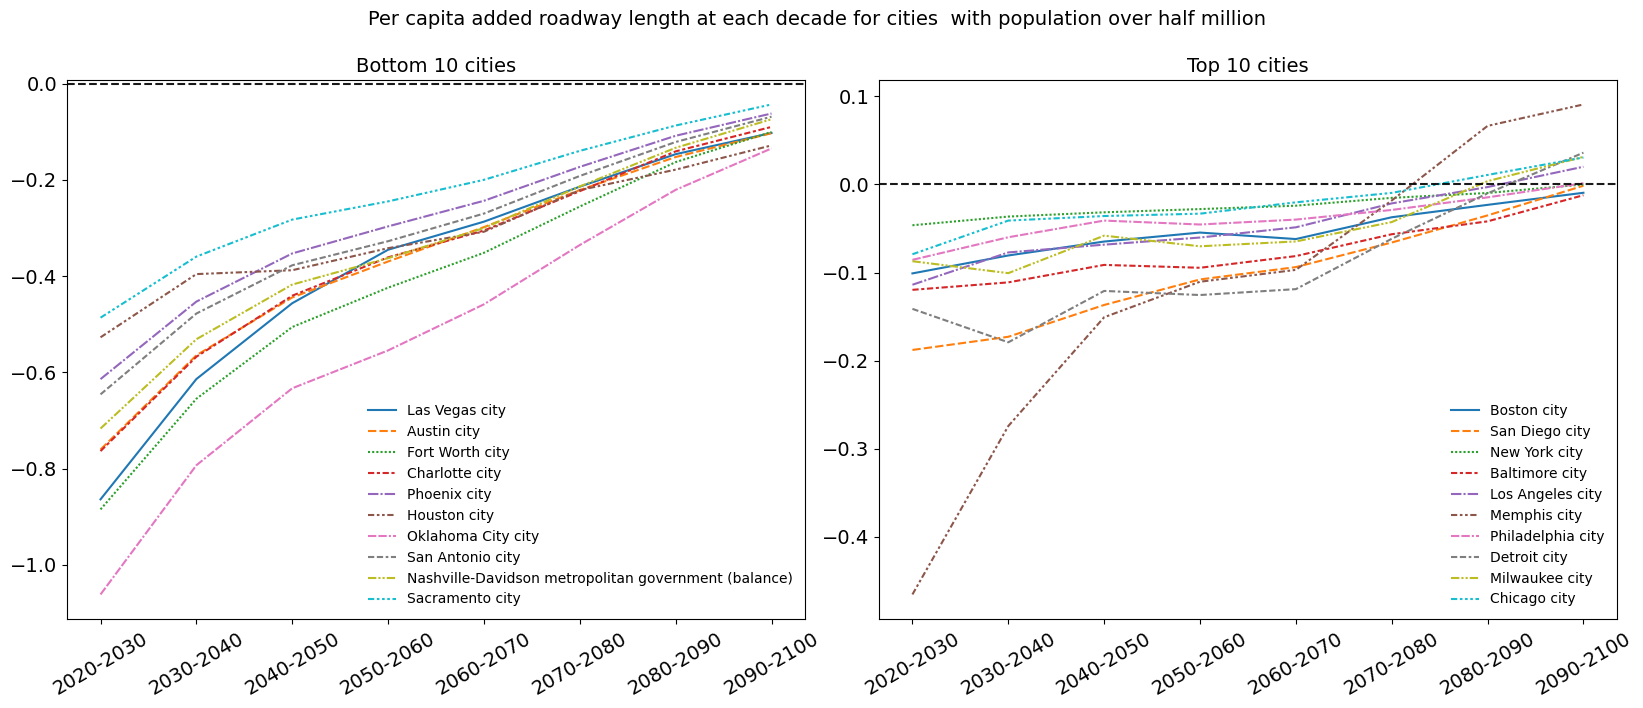

In [45]:
roads_df_sorted = roads_df[roads_df['CensusPop_20'] > 500000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 'per cap added from 2020-2030', 'per cap added from 2030-2040',
       'per cap added from 2040-2050', 'per cap added from 2050-2060', 'per cap added from 2060-2070', 'per cap added from 2070-2080',
       'per cap added from 2080-2090', 'per cap added from 2090-2100']]

lower_10 = roads_df_sorted.head(10).set_index('NAMELSAD') 
upper_10 = roads_df_sorted.tail(10).set_index('NAMELSAD') 

df_lineplot = [lower_10.T, upper_10.T]
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(20,7))
fig.suptitle('Per capita added roadway length at each decade for cities  with population over half million', fontsize= 14)
axes[0].set_title('Bottom 10 cities', fontsize= 14)
axes[1].set_title('Top 10 cities', fontsize= 14)
for ax , df in zip(axes, df_lineplot):
    sns.lineplot(ax= ax, data=df, legend = 'brief')
    # sns.move_legend(ax, loc = 2, bbox_to_anchor=(1, 1))
    ax.axhline(y=0, color = 'black', alpha = 0.9,linestyle= '--')
    ax.set_xticks(range(len(df)), ['2020-2030', '2030-2040','2040-2050','2050-2060','2060-2070','2070-2080','2080-2090','2090-2100'],rotation = 30)
    ax.tick_params(labelsize= 14)
    ax.legend(frameon=False)
plt.rc('legend',fontsize=14) 
plt.subplots_adjust(wspace=0.1, hspace=0.1)

# fig.savefig(figure_filepath + 'Per capita added roadway length at each decade for cities  with population over half million' + '.png', dpi = 300,  bbox_inches='tight')

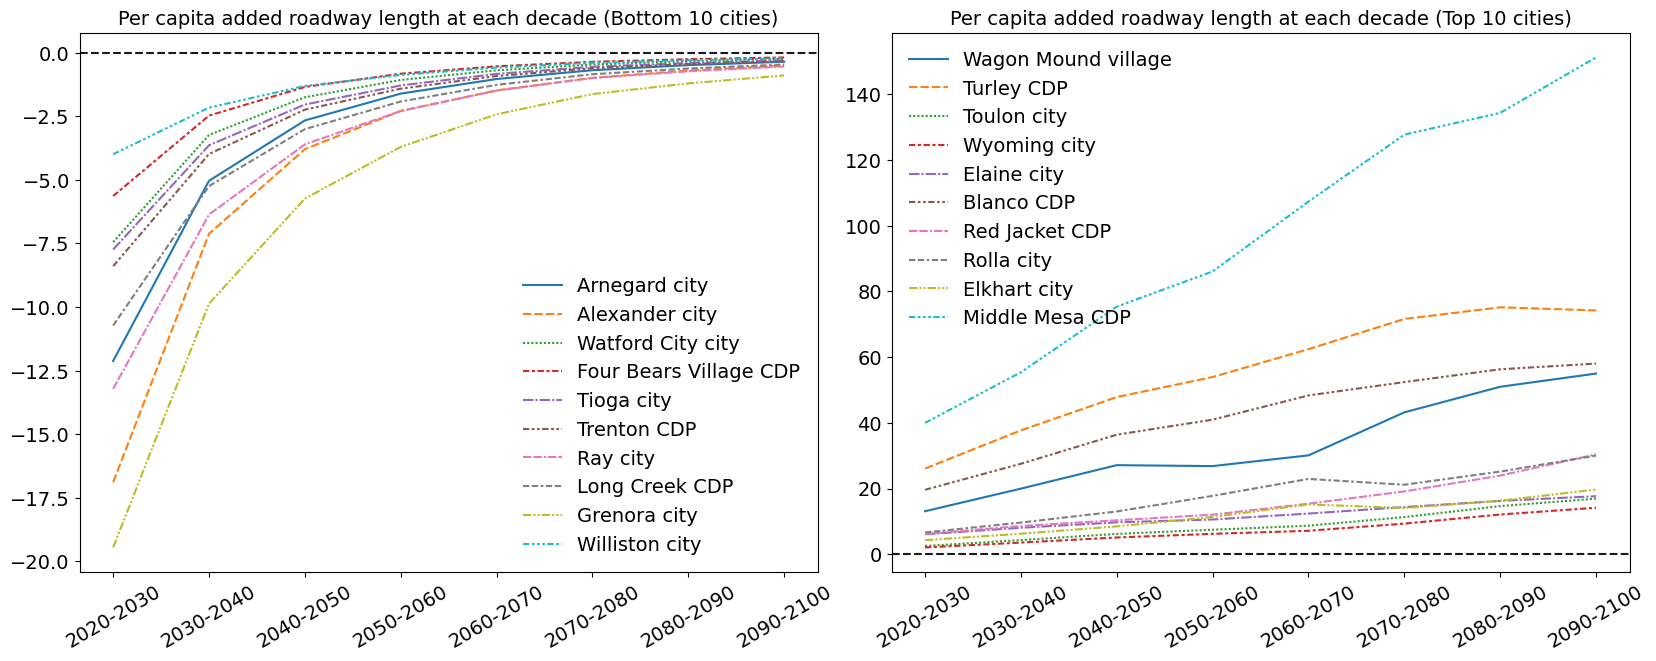

In [46]:
import seaborn as sns
roads_df_sorted = roads_df[roads_df['CensusPop_20'] > 100].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 'per cap added from 2020-2030', 'per cap added from 2030-2040',
       'per cap added from 2040-2050', 'per cap added from 2050-2060', 'per cap added from 2060-2070', 'per cap added from 2070-2080',
       'per cap added from 2080-2090', 'per cap added from 2090-2100']]

lower_10 = roads_df_sorted.head(10).set_index('NAMELSAD') 
upper_10 = roads_df_sorted.tail(10).set_index('NAMELSAD') 

df_lineplot = [lower_10.T, upper_10.T]
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(20,7))
# fig.suptitle('Top 10 cities with minimum and maximum percent change in per capita roadway')
axes[0].set_title('Per capita added roadway length at each decade (Bottom 10 cities)', fontsize= 14)
axes[1].set_title('Per capita added roadway length at each decade (Top 10 cities)', fontsize= 14)
for ax , df in zip(axes, df_lineplot):
    sns.lineplot(ax= ax, data=df, legend = 'brief')
    # sns.move_legend(ax, loc = 2, bbox_to_anchor=(1, 1))
    ax.axhline(y=0, color = 'black', alpha = 0.9,linestyle= '--')
    ax.set_xticks(range(len(df)), ['2020-2030', '2030-2040','2040-2050','2050-2060','2060-2070','2070-2080','2080-2090','2090-2100'],rotation = 30)
    ax.tick_params(labelsize= 14)
    ax.legend(frameon=False)
plt.rc('legend',fontsize=14) 
plt.subplots_adjust(wspace=0.1, hspace=0.1)

# fig.savefig(figure_filepath + 'Per capita added roadway length at each decade with population over 100' + '.png', dpi = 300,  bbox_inches='tight')

### starting from zero

In [47]:
roads_df = roads_df.assign(**roads_df[['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050', 
'per_cap_mass_at_2060', 'per_cap_mass_at_2070', 'per_cap_mass_at_2080', 'per_cap_mass_at_2090', 'per_cap_mass_at_2100']].sub(roads_df['per_cap_mass_at_2020'], axis=0).add_prefix('sub_'))

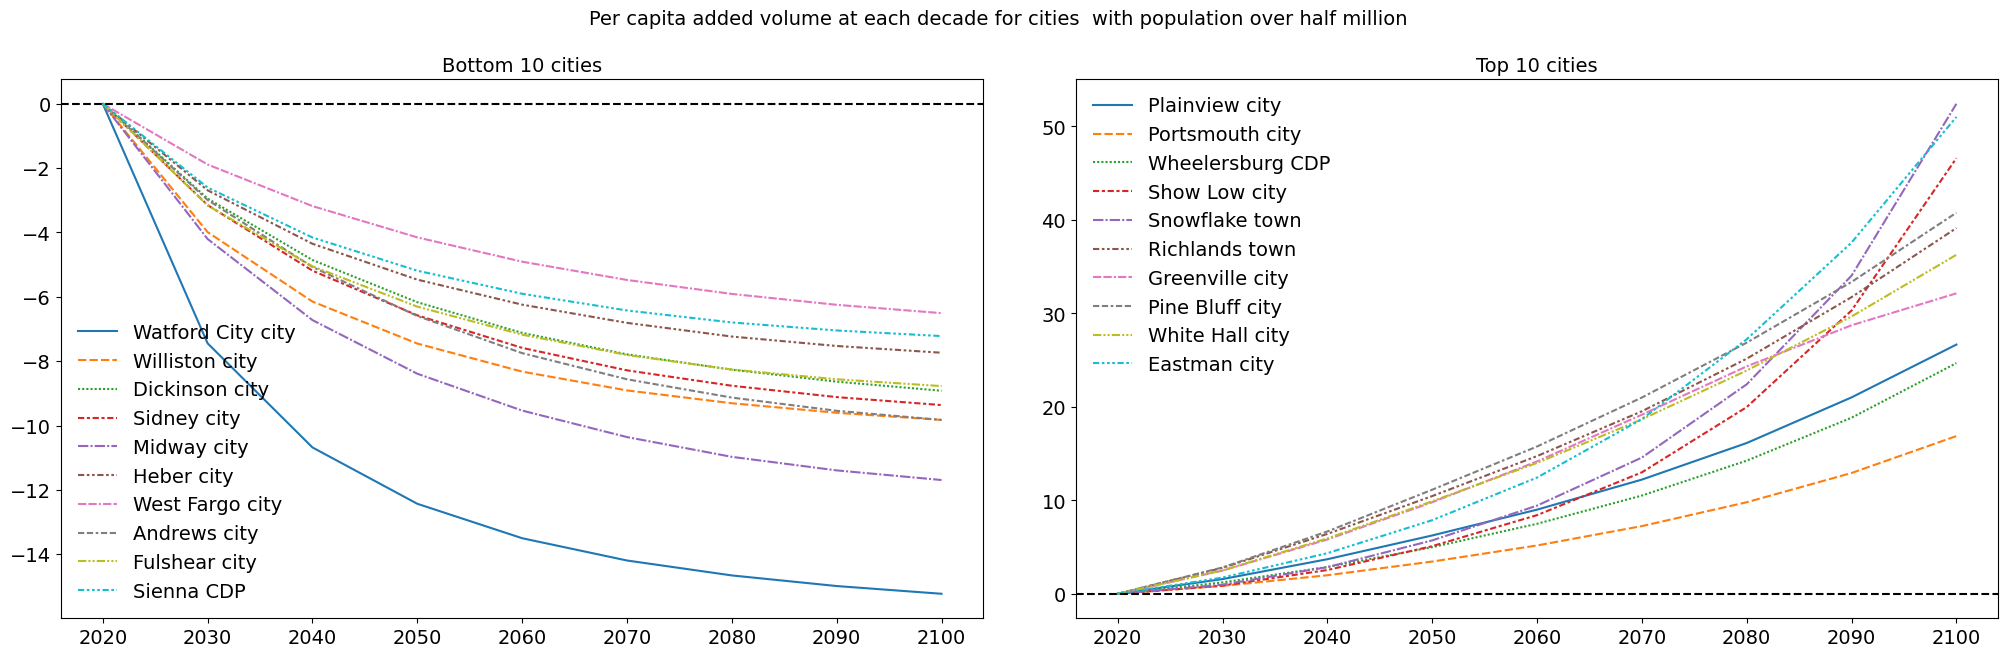

In [48]:
roads_df_sorted = roads_df[roads_df['CensusPop_20'] > 5000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 
        'sub_per_cap_mass_at_2020', 'sub_per_cap_mass_at_2030',
       'sub_per_cap_mass_at_2040', 'sub_per_cap_mass_at_2050',
       'sub_per_cap_mass_at_2060', 'sub_per_cap_mass_at_2070',
       'sub_per_cap_mass_at_2080', 'sub_per_cap_mass_at_2090',
       'sub_per_cap_mass_at_2100']]

# building_df_sorted = building_clean[building_clean['CensusPop_20'] > 500000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 'per_cap_mass_at_2020', 
#                                     'per_cap_mass_at_2030',  'per_cap_mass_at_2040',  'per_cap_mass_at_2050',  'per_cap_mass_at_2060', 
#                                     'per_cap_mass_at_2070',  'per_cap_mass_at_2080',  'per_cap_mass_at_2090',  'per_cap_mass_at_2100',]]

lower_10 = roads_df_sorted.head(10).set_index('NAMELSAD') 
upper_10 = roads_df_sorted.tail(10).set_index('NAMELSAD') 

df_lineplot = [lower_10.T, upper_10.T]
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(25,7))
fig.suptitle('Per capita added volume at each decade for cities  with population over half million', fontsize= 14)
axes[0].set_title('Bottom 10 cities', fontsize= 14)
axes[1].set_title('Top 10 cities', fontsize= 14)
for ax , df in zip(axes, df_lineplot):
    sns.lineplot(ax= ax, data=df, legend = True)
    # sns.move_legend(ax, loc = 2, bbox_to_anchor=(1, 1))
    ax.axhline(y=0, color = 'black', alpha = 1,linestyle= '--')
    ax.set_xticks(range(len(df)), ['2020', '2030','2040','2050','2060','2070','2080','2090', '2100']) #,rotation = 30)
    ax.tick_params(labelsize= 14)
    ax.legend(frameon=False)
plt.rc('legend',fontsize=14) 
plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [49]:
roads_df[['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2060', 'per_cap_mass_at_2100', 'percent change from 2060-2100', 'percent change from 2020-2060']].sort_values(by ='percent change from 2060-2100')
roads_df['Percentile Rank'] = roads_df['percent change from 2020-2060'].rank(pct = True) 

roads_df['city_type_pct_rank'] = roads_df.groupby('city type')['percent change from 2020-2060'].rank(pct=True)

In [50]:
from scipy.stats import zscore
# Calculate Z-score within each group
roads_df['z_score'] = roads_df.groupby('city type')['percent change from 2020-2060'].transform(lambda x: zscore(x))

In [51]:
figure_filepath = r'D:\Work\Box Sync\Quantify Infrastructure\Figures\\'

# # Import cartographic base maps: Cartographic boundary for plotting
US_counties_cb = gpd.read_file(r'D:\Work\Box Sync\Trends_all states\Maps_2020\cb_2020_us_county_5m.zip') # tl_2020_us_county
US_states_cb = gpd.read_file(r'D:\Work\Box Sync\Trends_all states\Maps_2020\cb_2020_us_state_5m.zip')  # tl_2020_us_state
# source: https://gis.stackexchange.com/questions/141580/which-projection-is-best-for-mapping-the-contiguous-united-states
US_states_cb = US_states_cb.to_crs('EPSG:9311')
US_counties_cb = US_counties_cb.to_crs('EPSG:9311')

import matplotlib

import matplotlib
def quantile_map_plot(df, list_of_columns, colors = 'viridis', is_county = False, state_code =None, file_path= None, file_name= None):

    colors = colors
    cmap = matplotlib.colors.ListedColormap([t[1] for t in sorted(colors.items())]) #Sorting by keys before converting to list


    if len(list_of_columns) > 1:
        
        fig, axes = plt.subplots(nrows=1, ncols=len(list_of_columns), figsize=(22,16)) #18,16 #len(list_of_columns)

        for ax, col in zip(axes.flatten(), list_of_columns):
            continental_ax = ax

            if is_county==True:
                color_subset = {key: value for key, value in colors.items() if key in  sorted(df[df['STATEFP'] == state_code][col].unique())}
                cmap = matplotlib.colors.ListedColormap([t[1] for t in sorted(color_subset.items())])
                US_counties_cb[US_counties_cb['STATEFP'] == state_code].plot(ax=continental_ax, facecolor = 'none', edgecolor='gray', linewidth=0.3)
                df[df['STATEFP'] == state_code].plot(ax= continental_ax, column = col, legend = True, linewidth=0.1, legend_kwds={'loc': 'lower left'}, 
                            cmap = cmap)
                
            else:
                # Set bounds to fit desired areas in each plot
                continental_ax.set_xlim(-2257388.37, 2695859.75)
                continental_ax.set_ylim(-2546944.04, 808080.90)

                # hawaii_ax = ax.inset_axes([.20, .01, .25, .2])

                US_states_cb.plot(ax=continental_ax, facecolor = 'none', edgecolor='gray', linewidth=0.3)
                df.plot(ax= continental_ax, column = col, legend = True, linewidth=0.1, legend_kwds={'loc': 'lower left'}, cmap = cmap)
            
                # US_states_cb[US_states_cb['STATEFP'] == '15'].plot(facecolor = 'none', edgecolor='gray', linewidth=0.2, ax=hawaii_ax)
                # print(df_map[df_map['STATEFP'] == '15'][col].unique())
                # df_map[df_map['STATEFP'] == '15'].plot(column=col, cmap = matplotlib.colors.ListedColormap(['orange', 'purple']), 
                #                             ax=hawaii_ax,  linewidth=0.3, missing_kwds = dict(color='black'))

            ax.set_title(col)
            # remove ticks
            for ax in [continental_ax]: #, hawaii_ax]:
                ax.set_yticks([])
                ax.set_xticks([])
                ax.axis('off')
                plt.tight_layout()
                plt.axis('off') 
    else:
        fig, continental_ax = plt.subplots(figsize=(16,22)) #18,16
        col = list_of_columns
        US_counties_cb.plot(ax=continental_ax, facecolor = 'none', edgecolor='gray', linewidth=0.3)
        df.plot(ax= continental_ax, column = col, legend = True, linewidth=0.4, legend_kwds={'loc': 'lower left'}, 
                        cmap = cmap)
        continental_ax.axis('off')



In [52]:
os.environ['USE_PYGEOS'] = '0'
# Import places map
places_US = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\MapData\all_places\compiled.shp')
print(places_US.shape)

places_50_states = places_US[(places_US['STATEFP'] != '02') & (places_US['STATEFP'] != '60') & (places_US['STATEFP'] != '66') & (places_US['STATEFP'] != '69') & (places_US['STATEFP'] != '72') & (places_US['STATEFP'] != '78')]

print(places_50_states.shape, roads_df.shape)

(32188, 17)
(31262, 17) (30537, 108)


In [53]:
df_map = places_50_states.merge(roads_df, on =['GEOID', 'NAMELSAD'])
print(df_map.shape)

df_map = df_map.to_crs('EPSG:9311')
df_map.columns

(30537, 123)


Index(['STATEFP', 'PLACEFP', 'PLACENS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'PCICBSA', 'PCINECTA',
       ...
       'sub_per_cap_mass_at_2040', 'sub_per_cap_mass_at_2050',
       'sub_per_cap_mass_at_2060', 'sub_per_cap_mass_at_2070',
       'sub_per_cap_mass_at_2080', 'sub_per_cap_mass_at_2090',
       'sub_per_cap_mass_at_2100', 'Percentile Rank', 'city_type_pct_rank',
       'z_score'],
      dtype='object', length=123)

In [55]:
# Function to categorize values based on quartile range
def categorize_by_quartiles(grouped_df, target_column):
    # Calculate quartile values
    Q1 = grouped_df.quantile(0.25)
    Q3 = grouped_df.quantile(0.75)

    # Categorize values based on quartiles
    def categorize_value(value):
        if value < Q1:
            return 'Pressurized'
        elif value > Q3:
            return 'Oversized'
        else:
            return 'Balanced'

    # Apply categorization to target_column
    return target_column.apply(categorize_value)

In [56]:
# Group data by 'group_column' before calculating quartiles
grouped = df_map.groupby('city type')

# Create a new column based on quartile values of values_column within each group
df_map['utilization_2020'] = grouped['per_cap_mass_at_2020'].transform(lambda x: categorize_by_quartiles(x, x))

# # Apply the same quartile thresholds to categorize target_column within each group
df_map['utilization_2040'] = grouped['per_cap_mass_at_2020'].transform(lambda x: categorize_by_quartiles(x, df_map['per_cap_mass_at_2040']))
df_map['utilization_2060'] = grouped['per_cap_mass_at_2020'].transform(lambda x: categorize_by_quartiles(x, df_map['per_cap_mass_at_2060']))
df_map['utilization_2080'] = grouped['per_cap_mass_at_2020'].transform(lambda x: categorize_by_quartiles(x, df_map['per_cap_mass_at_2080']))
df_map['utilization_2100'] = grouped['per_cap_mass_at_2020'].transform(lambda x: categorize_by_quartiles(x, df_map['per_cap_mass_at_2100']))

In [90]:
df_map.groupby(['city type'])[['per_cap_mass_at_2020','per_cap_mass_at_2040', 'per_cap_mass_at_2060', 'per_cap_mass_at_2080','per_cap_mass_at_2100']].quantile([0.25, 0.5, 0.75])

per_cap_mass_at_2020  per_cap_mass_at_2040  \
city type                                                    
periurban 0.25              9.137487              7.975591   
          0.50             13.662755             12.483845   
          0.75             20.121640             19.061953   
rural     0.25             22.035618             21.891004   
          0.50             33.640635             33.939386   
          0.75             57.859404             59.125937   
suburban  0.25              7.805023              6.939198   
          0.50             10.969029             10.015324   
          0.75             16.017313             15.083970   
urban     0.25              2.843566              2.651278   
          0.50              3.860839              3.658383   
          0.75              5.262257              5.052697   

                per_cap_mass_at_2060  per_cap_mass_at_2080  \
city type                                                    
periurban 0.25              7.270713              6.789930   
          0.50             11.904048             11.530708   
          0.75             18.710282             18.824081   
rural     0.25             22.389894             23.148223   
          0.50             35.437637             37.590081   
          0.75             62.587339             67.098429   
suburban  0.25              6.382129              6.005066   
          0.50              9.470601              9.161121   
          0.75             14.872290             15.017025   
urban     0.25              2.524522              2.472817   
          0.50              3.474181              3.385872   
          0.75              4.907072              4.684817   

                per_cap_mass_at_2100  
city type                             
periurban 0.25              6.651229  
          0.50             11.582138  
          0.75             19.735783  
rural     0.25             24.613322  
          0.50             41.320716  
          0.75             74.879316  
suburban  0.25              5.888001  
          0.50              9.242605  
          0.75             15.637168  
urban     0.25              2.474114  
          0.50              3.356107  
          0.75              4.634245

In [91]:
df_map[['utilization_2020', 'utilization_2040', 'utilization_2060', 'utilization_2080', 'utilization_2100']].apply(pd.Series.value_counts) *100/ df_map['utilization_2020'].value_counts().sum()

,utilization_2020,utilization_2040,utilization_2060,utilization_2080,utilization_2100
Balanced,49.995088,47.417886,45.371189,43.209877,41.428431
Oversized,25.002456,24.295117,25.176016,26.941088,29.970200
Pressurized,25.002456,28.286996,29.452795,29.849036,28.601369


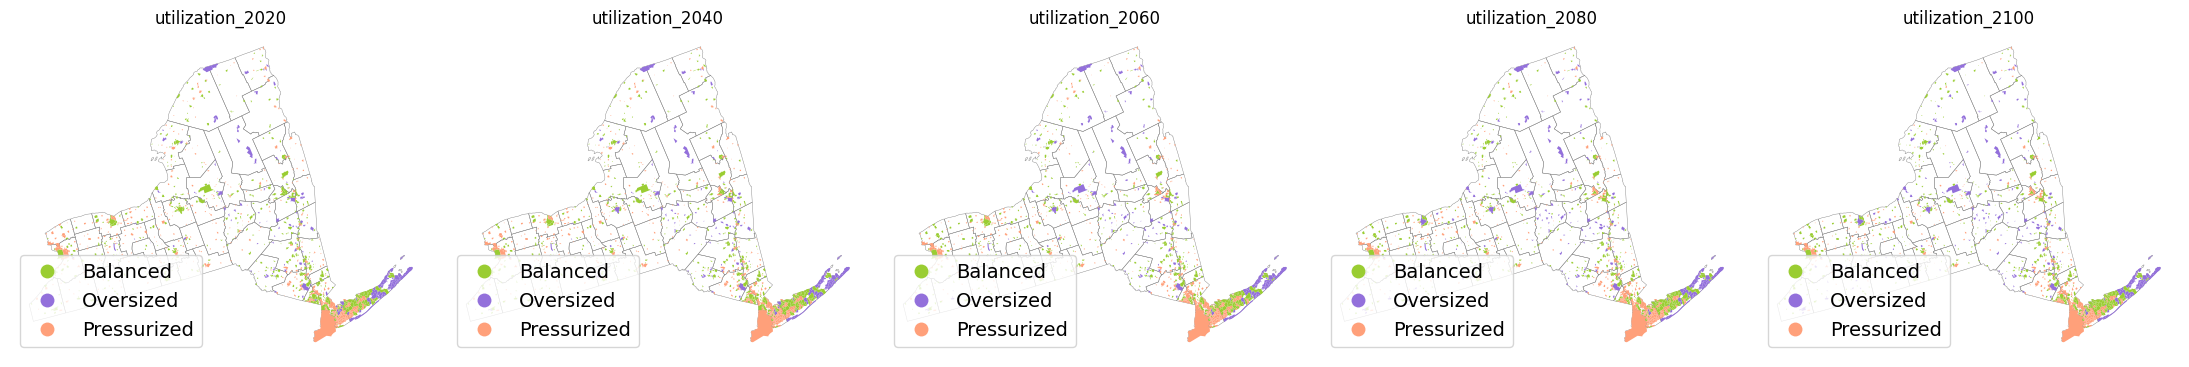

In [60]:
# from plot_functions import plot_50states
figure_filepath = r'D:\Work\Box Sync\Quantify Infrastructure\Figures\\'
figure_filename = 'plot_1'
figure_columns = ['utilization_2020', 'utilization_2040', 'utilization_2060', 'utilization_2080', 'utilization_2100']

colors = {
    'Balanced': 'yellowgreen', 
    # 'Balanced-over':  'darkolivegreen',
    'Oversized': 'mediumpurple',
    # 'Oversized-over': 'rebeccapurple',
    'Pressurized': 'lightsalmon', 
    # 'Pressurized-over': 'orangered'
}

quantile_map_plot(df_map, figure_columns, colors = colors, state_code ='36', is_county = True)

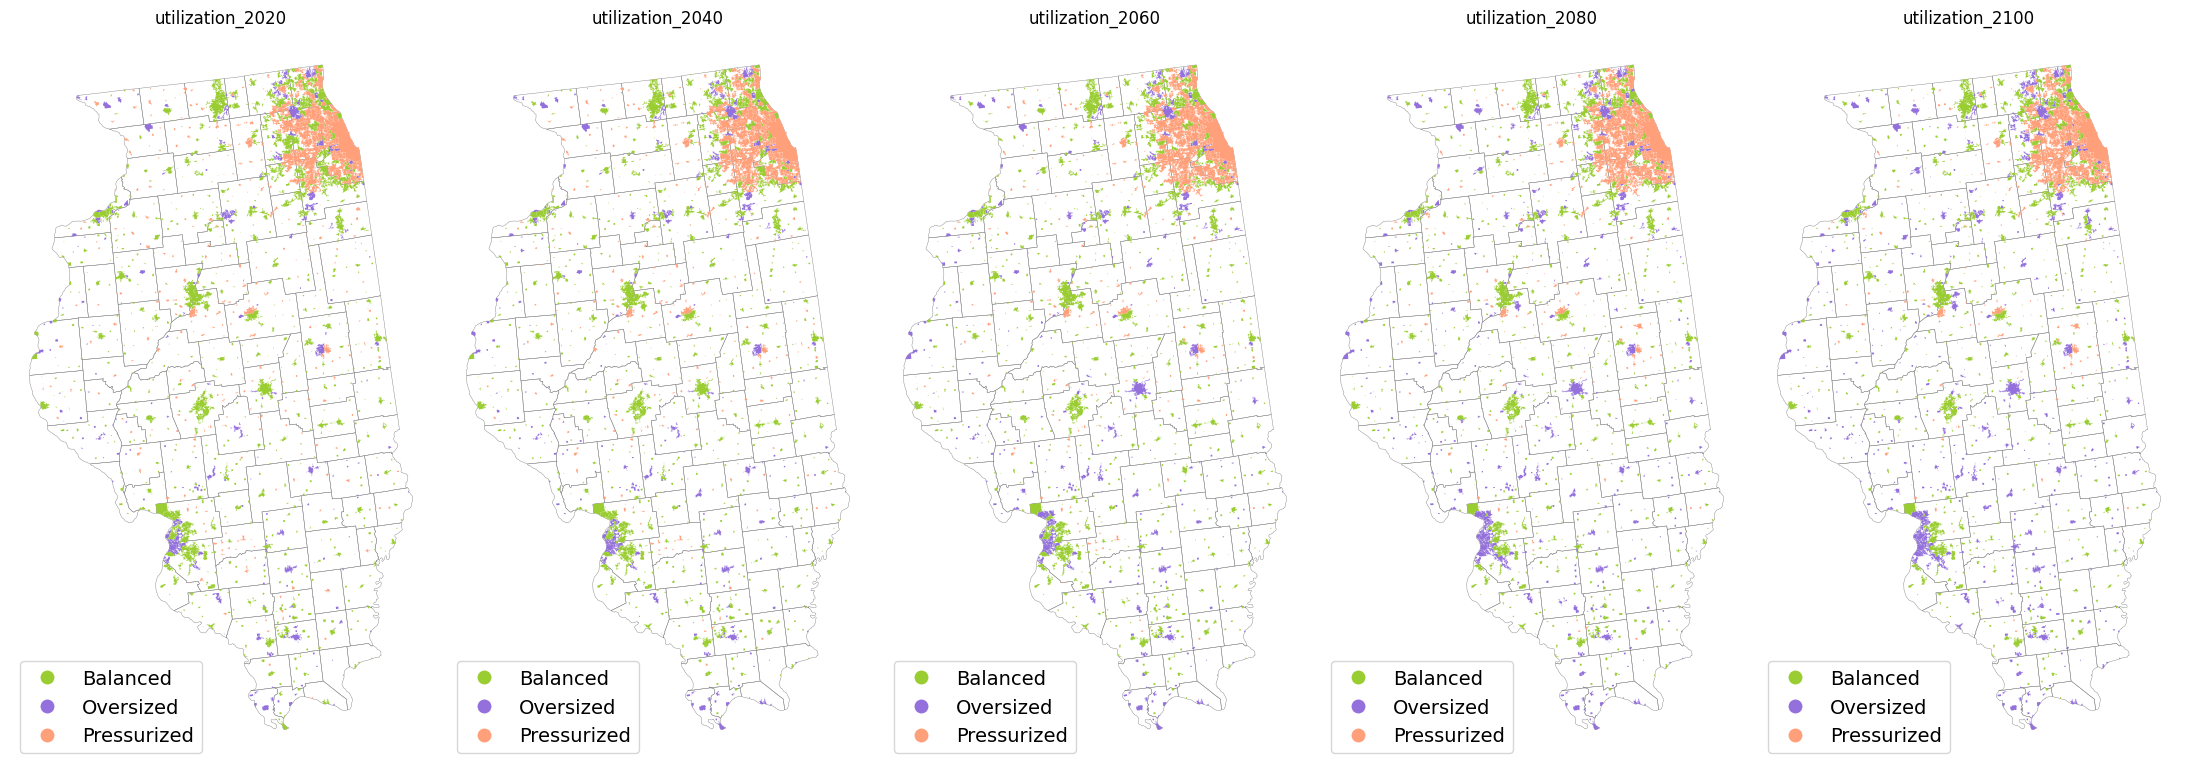

In [61]:
quantile_map_plot(df_map, figure_columns,  colors = colors, state_code ='17', is_county = True)

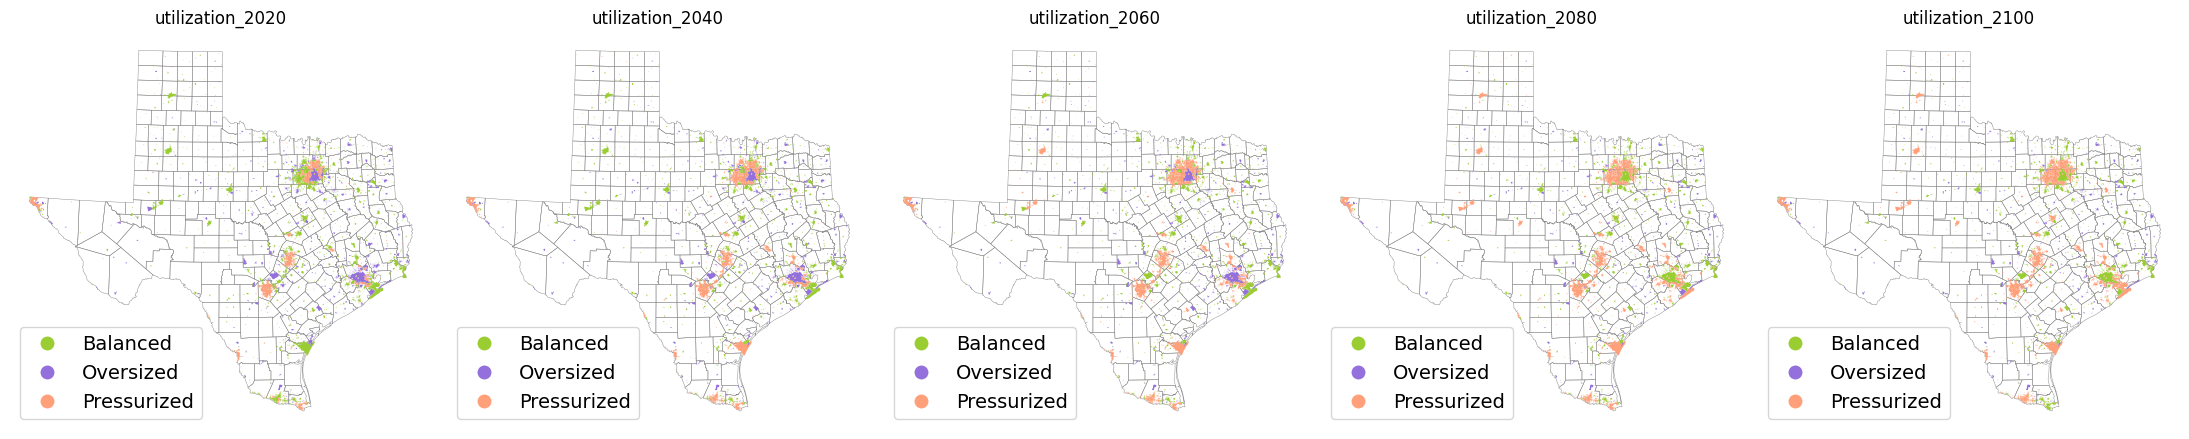

In [62]:
quantile_map_plot(df_map, figure_columns, colors = colors, state_code ='48', is_county = True)

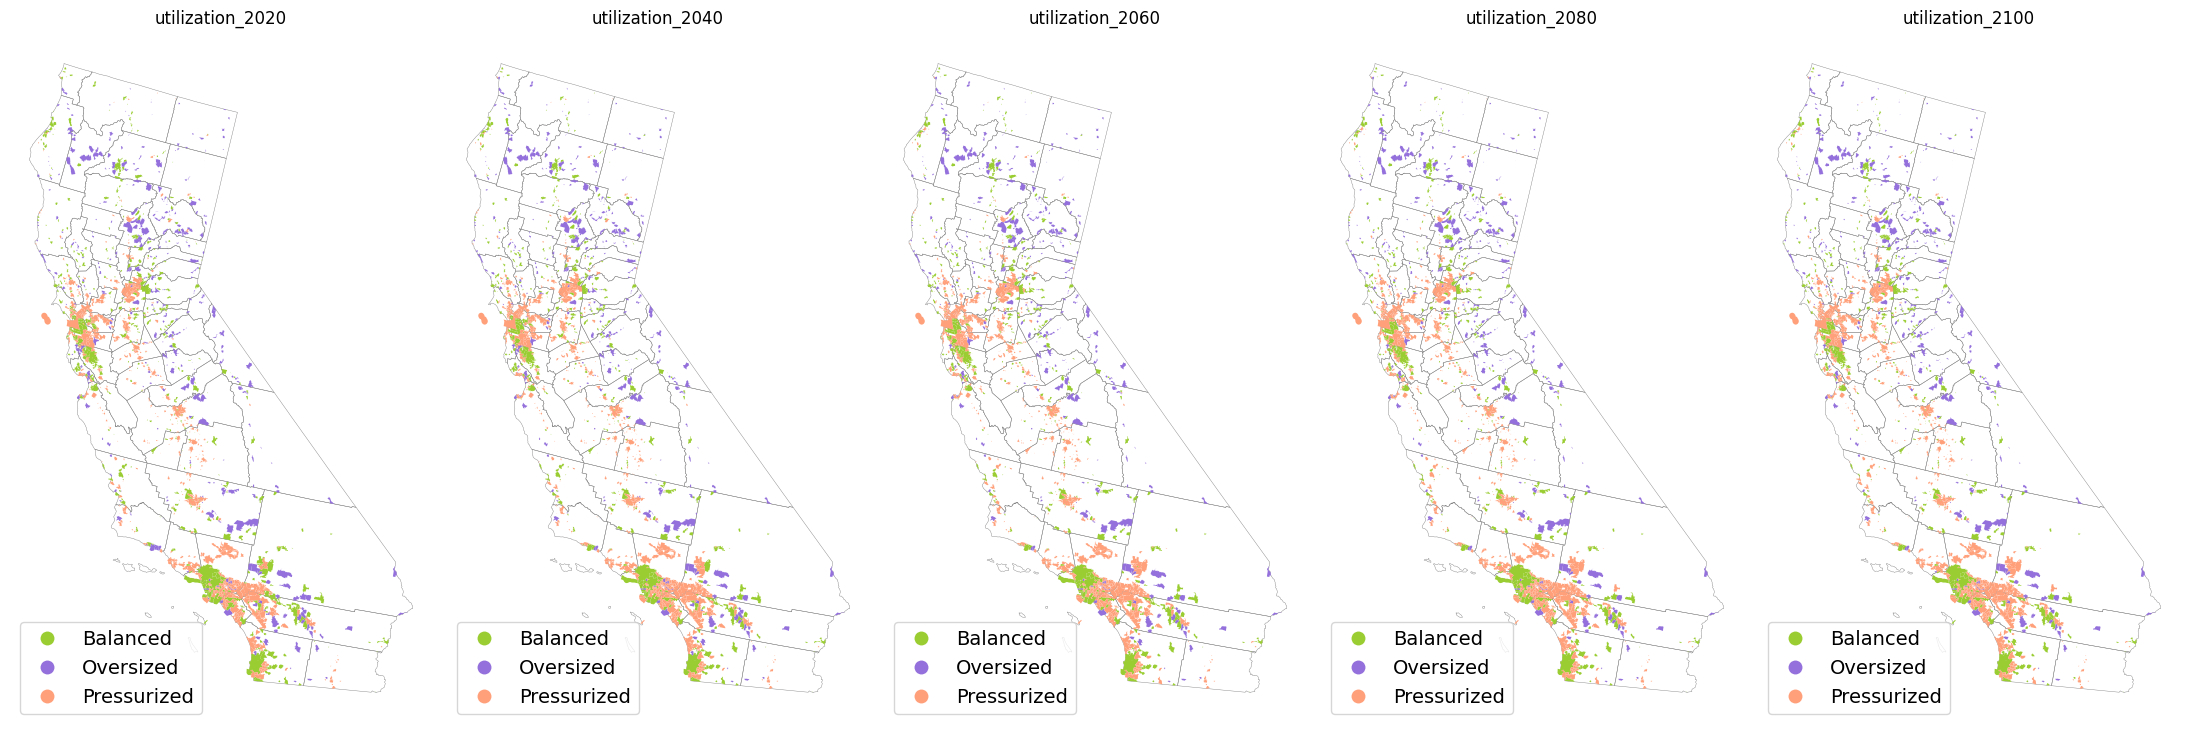

In [63]:
quantile_map_plot(df_map, figure_columns, colors = colors, state_code ='06', is_county = True)

### Add landuse data from 2019

In [64]:
df_nlcd = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GEE_NLCD_landuse\LandCoverbyCity19.csv')
df_nlcd['GEOID'] = df_nlcd['GEOID'].astype(str).str.rjust(7,'0')

column_names = ['Open_water', 'Perennial_ice_snow', 'Developed_open_space','Developed_low_intensity', 'Developed_medium_intensity',
       'Developed_high_intensity', 'Barren_land', 'Deciduous_forest', 'Evergreen_forest', 'Mixed_forest', 'Dwarf_scrub', 'Shrub_scrub',
       'Grassland_herbaceous', 'Sedge_herbaceous', 'Lichens', 'Moss', 'Pasture_hay', 'Cultivated_crops', 'Woody_wetland', 'EmergentherbaceousWetlands']

df_nlcd[column_names] = df_nlcd[column_names].div(df_nlcd[column_names].sum(axis=1), axis=0).multiply(100)
df_nlcd = df_nlcd.fillna(0)

df_nlcd['veg_wetland'] = df_nlcd[['Dwarf_scrub', 'Shrub_scrub', 'Grassland_herbaceous', 'Sedge_herbaceous', 'Lichens', 'Moss',
       'Pasture_hay', 'Cultivated_crops', 'Woody_wetland', 'EmergentherbaceousWetlands', 'Perennial_ice_snow']].sum(axis=1)
df_nlcd['forest'] = df_nlcd[['Deciduous_forest','Evergreen_forest', 'Mixed_forest']].sum(axis=1)

In [65]:
roads_df_lu = df_map.merge(df_nlcd[['GEOID', 'Open_water','veg_wetland', 'forest', 'Barren_land', 'Developed_open_space', 
'Developed_low_intensity', 'Developed_medium_intensity', 'Developed_high_intensity']], on ='GEOID')

roads_df_lu['otherLU'] = roads_df_lu[['Open_water','veg_wetland', 'forest', 'Barren_land']].sum(axis=1)
roads_df_lu['developedLU'] = roads_df_lu[['Developed_open_space','Developed_low_intensity', 'Developed_medium_intensity', 'Developed_high_intensity']].sum(axis=1)

In [66]:
roads_df_lu[(roads_df_lu['developedLU'] > 0) & (roads_df_lu['utilization_2100'] == 'Pressurized')][['State', 'CensusPop_20', 'city type', 'NAMELSAD', 'per_cap_mass_at_2020', 'per_cap_mass_at_2060', 
                                             'utilization_2020', 'utilization_2060','utilization_2100', 'otherLU',
       'developedLU']].sort_values(by='developedLU')

,State,CensusPop_20,city type,NAMELSAD,per_cap_mass_at_2020,per_cap_mass_at_2060,utilization_2020,utilization_2060,utilization_2100,otherLU,developedLU
2528,6.0,69.0,rural,Hartland CDP,13.802846,13.633555,Pressurized,Pressurized,Pressurized,99.157701,0.842299
24858,46.0,308.0,rural,Bullhead CDP,33.574723,25.231311,Balanced,Balanced,Pressurized,98.886030,1.113970
17014,35.0,1193.0,rural,Iyanbito CDP,32.563639,20.668841,Balanced,Pressurized,Pressurized,97.803705,2.196295
15160,30.0,97.0,rural,East Malta Colony CDP,12.892230,13.953943,Pressurized,Pressurized,Pressurized,97.752606,2.247394
24860,46.0,76.0,rural,Camrose Colony CDP,12.670469,11.412060,Pressurized,Pressurized,Pressurized,97.415373,2.584627
...,...,...,...,...,...,...,...,...,...,...,...
17880,36.0,5220.0,periurban,Albertson CDP,5.624757,4.994168,Pressurized,Pressurized,Pressurized,0.000000,100.000000
17745,36.0,2645.0,suburban,East Williston village,6.654732,6.009676,Pressurized,Pressurized,Pressurized,0.000000,100.000000
4692,12.0,5092.0,suburban,Naples Park CDP,8.743222,6.441381,Balanced,Pressurized,Pressurized,0.000000,100.000000
2973,6.0,1913.0,periurban,Rouse CDP,3.810599,3.086055,Pressurized,Pressurized,Pressurized,0.000000,100.000000


In [67]:
roads_df_lu[roads_df_lu['developedLU'] > 0][['utilization_2020', 'utilization_2060','utilization_2100']].apply(pd.Series.value_counts)

,utilization_2020,utilization_2060,utilization_2100
Balanced,15229,13829,12632
Oversized,7627,7685,9149
Pressurized,7519,8861,8594


In [68]:
roads_df_lu[roads_df_lu['developedLU'] == 0][['utilization_2020', 'utilization_2060','utilization_2100']].apply(pd.Series.value_counts)

,utilization_2020,utilization_2060,utilization_2100
Pressurized,116,133,140
Balanced,38,26,19
Oversized,8,3,3


In [69]:
# Land use data is not available for Hawaii
roads_df_lu[roads_df_lu['developedLU'] == 0][['State', 'CensusPop_20', 'NAMELSAD', 'per_cap_mass_at_2020', 'per_cap_mass_at_2060', 
                                            'utilization_2020', 'utilization_2060','utilization_2100', 'otherLU',
       'developedLU']].sort_values(by=['CensusPop_20','utilization_2100']).tail(141)

,State,CensusPop_20,NAMELSAD,per_cap_mass_at_2020,per_cap_mass_at_2060,utilization_2020,utilization_2060,utilization_2100,otherLU,developedLU
5743,15.0,512.0,Seaview CDP,28.248293,19.969695,Balanced,Pressurized,Pressurized,0.0,0.0
5630,15.0,550.0,Haena CDP,7.672502,6.726182,Pressurized,Pressurized,Pressurized,0.0,0.0
5744,15.0,555.0,Tiki Gardens CDP,2.347213,1.665321,Pressurized,Pressurized,Pressurized,0.0,0.0
5724,15.0,618.0,Paauilo CDP,10.064078,7.104171,Pressurized,Pressurized,Pressurized,0.0,0.0
5677,15.0,672.0,Kaumakani CDP,7.705048,5.219337,Pressurized,Pressurized,Pressurized,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
5770,15.0,43485.0,Waipahu CDP,2.133913,1.630702,Pressurized,Pressurized,Pressurized,0.0,0.0
5649,15.0,44186.0,Hilo CDP,9.055650,6.821626,Balanced,Pressurized,Pressurized,0.0,0.0
5731,15.0,45295.0,Pearl City CDP,3.828355,2.962151,Pressurized,Pressurized,Pressurized,0.0,0.0
5621,15.0,50922.0,East Honolulu CDP,4.074853,3.286411,Pressurized,Pressurized,Pressurized,0.0,0.0


In [70]:
roads_df_lu[roads_df_lu['State'] == 17][['utilization_2020', 'utilization_2040', 'utilization_2060',
                                          'utilization_2080', 'utilization_2100']].apply(pd.Series.value_counts)/roads_df_lu[roads_df_lu['State'] == 17].shape[0]

,utilization_2020,utilization_2040,utilization_2060,utilization_2080,utilization_2100
Balanced,0.542160,0.542160,0.537979,0.500348,0.461324
Oversized,0.155401,0.176307,0.216725,0.280836,0.352613
Pressurized,0.302439,0.281533,0.245296,0.218815,0.186063


In [71]:
roads_df_lu[roads_df_lu['State'] == 6][['utilization_2020', 'utilization_2040', 'utilization_2060', 
                                        'utilization_2080', 'utilization_2100']].apply(pd.Series.value_counts)/ roads_df_lu[roads_df_lu['State'] == 6].shape[0]

,utilization_2020,utilization_2040,utilization_2060,utilization_2080,utilization_2100
Pressurized,0.413443,0.460368,0.481294,0.492708,0.488269
Balanced,0.326569,0.289791,0.279011,0.262524,0.261256
Oversized,0.259987,0.249841,0.239696,0.244769,0.250476


In [72]:
roads_df_lu[roads_df_lu['State'] == 36][['utilization_2020', 'utilization_2040', 'utilization_2060',
                                          'utilization_2080', 'utilization_2100']].apply(pd.Series.value_counts)/roads_df_lu[roads_df_lu['State'] == 36].shape[0]

,utilization_2020,utilization_2040,utilization_2060,utilization_2080,utilization_2100
Balanced,0.428793,0.423375,0.428019,0.430341,0.452012
Oversized,0.129257,0.132353,0.146285,0.167183,0.192724
Pressurized,0.441950,0.444272,0.425697,0.402477,0.355263


In [73]:
roads_df_lu[roads_df_lu['State'] == 48][['utilization_2020', 'utilization_2040', 'utilization_2060', 
                                         'utilization_2080', 'utilization_2100']].apply(pd.Series.value_counts)/roads_df_lu[roads_df_lu['State'] == 48].shape[0]

,utilization_2020,utilization_2040,utilization_2060,utilization_2080,utilization_2100
Balanced,0.529929,0.478309,0.450851,0.417902,0.395387
Oversized,0.283361,0.238880,0.213619,0.212521,0.230093
Pressurized,0.186711,0.282812,0.335530,0.369577,0.374519


In [74]:
roads_df_lu[roads_df_lu['State'] == 49][['utilization_2020', 'utilization_2040', 'utilization_2060', 
                                         'utilization_2080', 'utilization_2100']].apply(pd.Series.value_counts)/roads_df_lu[roads_df_lu['State'] == 49].shape[0]

,utilization_2020,utilization_2040,utilization_2060,utilization_2080,utilization_2100
Balanced,0.483384,0.386707,0.338369,0.320242,0.314199
Oversized,0.283988,0.253776,0.244713,0.238671,0.238671
Pressurized,0.232628,0.359517,0.416918,0.441088,0.447130


In [75]:
roads_df_lu[roads_df_lu['State'] == 53][['utilization_2020', 'utilization_2040', 'utilization_2060', 
                                         'utilization_2080', 'utilization_2100']].apply(pd.Series.value_counts)/roads_df_lu[roads_df_lu['State'] == 53].shape[0]

,utilization_2020,utilization_2040,utilization_2060,utilization_2080,utilization_2100
Balanced,0.485849,0.454403,0.424528,0.389937,0.377358
Oversized,0.194969,0.161950,0.144654,0.150943,0.163522
Pressurized,0.319182,0.383648,0.430818,0.459119,0.459119


In [76]:
roads_df_lu[roads_df_lu['city type'] == 'rural'][['NAMELSAD', 'utilization_2020', 'utilization_2060', 'utilization_2100', 'per_cap_mass_at_2020',
                                           'per_cap_mass_at_2040', 'per_cap_mass_at_2060','per_cap_mass_at_2100',
                                           'otherLU','developedLU']].sort_values('per_cap_mass_at_2060').tail(20)

,NAMELSAD,utilization_2020,utilization_2060,utilization_2100,per_cap_mass_at_2020,per_cap_mass_at_2040,per_cap_mass_at_2060,per_cap_mass_at_2100,otherLU,developedLU
17068,Lybrook CDP,Oversized,Oversized,Oversized,1157.049492,1304.613525,1609.839835,2379.026567,93.502836,6.497164
23437,Fort Indiantown Gap CDP,Oversized,Oversized,Oversized,1807.819033,1699.493132,1635.415568,1593.237418,82.009271,17.990729
30471,Fontenelle CDP,Oversized,Oversized,Oversized,1814.774973,1745.034974,1697.505567,1753.032299,97.835996,2.164004
3527,Cathedral CDP,Oversized,Oversized,Oversized,1360.162821,1506.928999,1699.454563,1881.629262,98.756999,1.243001
2698,Little Grass Valley CDP,Oversized,Oversized,Oversized,1394.898960,1669.271010,1897.954951,2395.611745,98.394162,1.605838
17034,Lake Sumner CDP,Oversized,Oversized,Oversized,1694.649801,1905.328814,2129.972685,2761.250327,99.683957,0.316043
972,Sunwest CDP,Oversized,Oversized,Oversized,2106.562113,2290.110236,2308.556601,2554.327480,98.843710,1.156290
17107,Newkirk CDP,Oversized,Oversized,Oversized,1830.849121,2083.413002,2910.213841,4918.480687,87.742151,12.257849
2888,Pearsonville CDP,Oversized,Oversized,Oversized,2521.872144,2541.435737,2948.506431,4344.278929,92.623828,7.376172
24921,Okaton CDP,Oversized,Oversized,Oversized,2226.728414,2681.482489,2986.514474,1997.276060,97.318445,2.681555


### Check quantiles after dropping outliers (extreme values)

In [77]:
# Function to remove outliers using IQR method and recalculate quantiles for a specific column
def remove_outliers_and_recalculate_quantiles_for_column(df, column_name):
    # Extract the specified column
    column = df[column_name]
    print("Initial dataframe shape", df.shape)

    # Calculate IQR
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    print("quantile values before excluding outliers:")
    print(Q1.round(2), Q3.round(2))

    # Define lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter DataFrame to exclude outliers
    df_filtered = df[(column >= lower_bound) & (column <= upper_bound)]

    # Recalculate quantile values after excluding outliers
    quantiles = df_filtered[column_name].quantile([0.25, 0.75])
    print("quantile values after excluding outliers:")
    print(quantiles)
    print("New dataframe shape", df_filtered.shape)
    print('\n')

    return df_filtered, quantiles

In [78]:
df_filtered, quantiles = remove_outliers_and_recalculate_quantiles_for_column(df_map[df_map['city type'] == 'urban'], 'per_cap_mass_at_2020')
df_filtered, quantiles = remove_outliers_and_recalculate_quantiles_for_column(df_map[df_map['city type'] == 'suburban'], 'per_cap_mass_at_2020')
df_filtered, quantiles = remove_outliers_and_recalculate_quantiles_for_column(df_map[df_map['city type'] == 'periurban'], 'per_cap_mass_at_2020')
df_filtered, quantiles = remove_outliers_and_recalculate_quantiles_for_column(df_map[df_map['city type'] == 'rural'], 'per_cap_mass_at_2020')

Initial dataframe shape (312, 128)
quantile values before excluding outliers:
2.84 5.26
quantile values after excluding outliers:
0.25    2.819227
0.75    5.073500
Name: per_cap_mass_at_2020, dtype: float64
New dataframe shape (304, 128)


Initial dataframe shape (6885, 128)
quantile values before excluding outliers:
7.81 16.02
quantile values after excluding outliers:
0.25     7.637311
0.75    14.888575
Name: per_cap_mass_at_2020, dtype: float64
New dataframe shape (6499, 128)


Initial dataframe shape (5698, 128)
quantile values before excluding outliers:
9.14 20.12
quantile values after excluding outliers:
0.25     8.932413
0.75    18.783598
Name: per_cap_mass_at_2020, dtype: float64
New dataframe shape (5376, 128)


Initial dataframe shape (17642, 128)
quantile values before excluding outliers:
22.04 57.86
quantile values after excluding outliers:
0.25    21.169913
0.75    48.694710
Name: per_cap_mass_at_2020, dtype: float64
New dataframe shape (16069, 128)




In [79]:
roads_df_lu.groupby(['State', 'utilization_2020', 'utilization_2060','utilization_2100']).size().head(20)

State  utilization_2020  utilization_2060  utilization_2100
1.0    Balanced          Balanced          Balanced            176
                                           Oversized            56
                                           Pressurized           7
                         Oversized         Balanced              1
                                           Oversized            32
                         Pressurized       Pressurized          15
       Oversized         Balanced          Balanced             25
                                           Oversized             4
                         Oversized         Balanced              2
                                           Oversized           259
       Pressurized       Balanced          Balanced              3
                         Pressurized       Balanced              2
                                           Pressurized           9
4.0    Balanced          Balanced          Balanced            102
  

### Plot temporal shift

In [80]:
# roads_clean[['city type','percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].describe()

<Axes: >

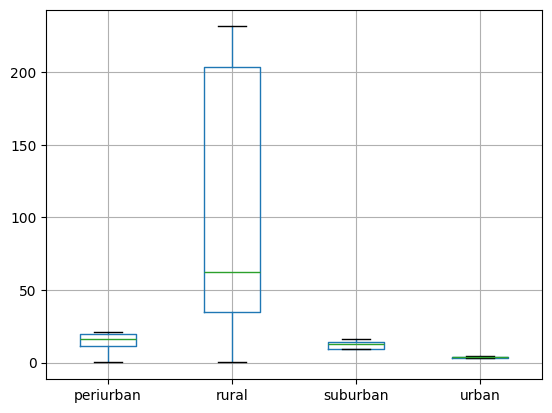

In [81]:
roads_clean.groupby('city type').agg(
    {'per_cap_mass_at_2020': ["min", "max", "median", "mean", "std"],
     'per_cap_mass_at_2040': ["min", "max", "median", "mean", "std"],
     'per_cap_mass_at_2050': ["min", "max", "median", "mean", "std"],
     'per_cap_mass_at_2060': ["min", "max", "median", "mean", "std"],
     'per_cap_mass_at_2070': ["min", "max", "median", "mean", "std"],
     'per_cap_mass_at_2080': ["min", "max", "median", "mean", "std"],
     'per_cap_mass_at_2090': ["min", "max", "median", "mean", "std"],
     'per_cap_mass_at_2100': ["min", "max", "median", "mean", "std"],}
).T.boxplot(showfliers=False)

In [82]:
roads_clean[roads_clean['future trend from SSP 2'] == 'decreasing']

,GEOID,NAMELSAD,motorway,trunk,primary,secondary,tertiary,unclassified,residential,cl_motorway,...,per_cap_mass_at_2080,surface_Res_at_2080,per_cap_mass_at_2090,surface_Res_at_2090,per_cap_mass_at_2100,surface_Res_at_2100,percent change from 2020-2040,percent change from 2040-2060,percent change from 2060-2080,percent change from 2080-2100
2,0171496,Somerville town,0.0,0.000000,0.000000,16702.050370,0.000000,0.000000,42007.387675,0.0,...,40.965157,28979.351339,43.062450,28979.351339,45.533860,28979.351339,-0.001026,0.050702,0.072204,0.111527
3,0176872,Trinity town,0.0,3921.732830,0.000000,0.000000,24753.439644,3779.474886,64473.206717,0.0,...,19.617740,49796.597879,19.939685,49796.597879,20.357311,49796.597879,-0.020001,0.006310,0.012278,0.037699
5,0121280,Double Springs town,0.0,171.978013,13089.159212,14083.160403,2299.660340,2888.013598,72385.447351,0.0,...,60.033394,51643.523820,63.741713,51643.523820,67.793081,51643.523820,0.068938,0.101903,0.104361,0.129256
6,0132704,Haleyville city,0.0,0.000000,14015.106291,10067.000459,20905.014513,19389.335772,168394.569903,0.0,...,26.307159,115144.344296,26.888454,115144.344296,27.625018,115144.344296,-0.025780,0.006248,0.017623,0.050095
7,0153376,Natural Bridge town,0.0,125.701419,5007.534812,0.000000,1452.253378,0.000000,2067.479202,0.0,...,238.168785,5918.934125,255.387706,5918.934125,268.963688,5918.934125,0.059054,0.113025,0.092366,0.129299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30505,5658970,Osmond CDP,0.0,5621.456475,0.000000,8614.049806,0.000000,3715.817284,15947.704039,0.0,...,42.979390,16962.997368,44.678176,16962.997368,47.000651,16962.997368,-0.041011,0.026336,0.043410,0.093563
30516,5667670,Ryan Park CDP,0.0,0.000000,0.000000,3195.283491,0.000000,9674.096215,13884.444752,0.0,...,421.913750,13413.775375,429.852405,13413.775375,446.332267,13413.775375,-0.018200,0.059030,0.001038,0.057876
30524,5675572,Taylor CDP,0.0,0.000000,0.000000,0.000000,0.000000,10149.761043,4644.377459,0.0,...,72.386060,7410.518123,75.366530,7410.518123,79.030333,7410.518123,-0.044865,0.027392,0.037117,0.091789
30526,5678400,Turnerville CDP,0.0,0.000000,0.000000,0.000000,0.000000,3695.365481,41309.428640,0.0,...,103.866420,22528.073793,108.005425,22528.073793,113.548286,22528.073793,-0.042405,0.026940,0.042011,0.093215


In [83]:
# px_data = roads_clean[roads_clean['city type'] == 'urban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060', 'per_cap_mass_at_2070',
#              'per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']]
# x = [2020, 2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100] 
# y = px_data[['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060', 'per_cap_mass_at_2070',
#              'per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values

# import plotly.express as px
# df = px_data
# fig = px.scatter(px_data, x=px_data.index, y='per_cap_mass_at_2020')
# fig = px.scatter(px_data, x='per_cap_mass_at_2020', y='per_cap_mass_at_2080', color = 'per_cap_mass_at_2060')
# fig.show()

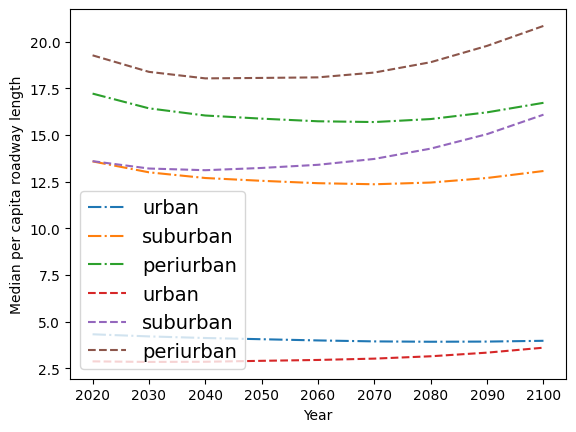

In [84]:
x = [2020, 2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100] 
y1 = roads_clean[roads_clean['city type'] == 'urban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values
y2 = roads_clean[roads_clean['city type'] == 'suburban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values
y3 = roads_clean[roads_clean['city type'] == 'periurban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values
y4 = roads_clean[roads_clean['city type'] == 'rural'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values
plt.plot(x, y1, '-.', label ='urban')
plt.plot(x, y2, '-.', label ='suburban')
plt.plot(x, y3, '-.', label ='periurban')
# plt.plot(x, y4, '-.', label ='rural')

y11 = roads_clean[roads_clean['city type'] == 'urban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].std(axis=0).values
y22 = roads_clean[roads_clean['city type'] == 'suburban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].std(axis=0).values
y33 = roads_clean[roads_clean['city type'] == 'periurban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].std(axis=0).values
y44 = roads_clean[roads_clean['city type'] == 'rural'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].std(axis=0).values
plt.plot(x, y11, '--', label ='urban')
plt.plot(x, y22, '--', label ='suburban')
plt.plot(x, y33, '--', label ='periurban')
# plt.plot(x, y44, '--', label ='rural')

plt.xlabel("Year")
plt.ylabel("Median per capita roadway length")
plt.legend()
# plt.title('multiple plots')
plt.show()

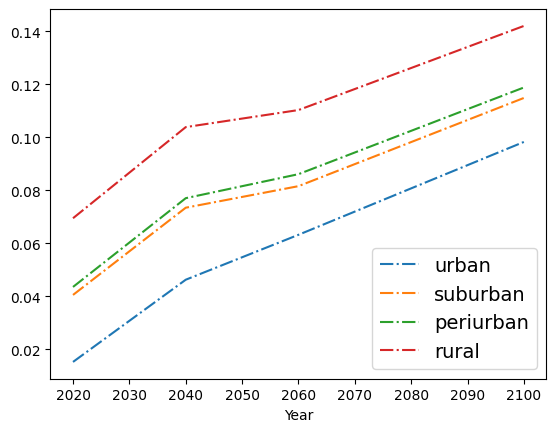

In [85]:
df_decreasing  = roads_clean[roads_clean['future trend from SSP 2'] == 'decreasing']
x = [2020,2040,2060,2100] 
y1 = df_decreasing[df_decreasing['city type'] == 'urban'][['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=0).values
y2 = df_decreasing[df_decreasing['city type'] == 'suburban'][['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=0).values
y3 = df_decreasing[df_decreasing['city type'] == 'periurban'][['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=0).values
y4 = df_decreasing[df_decreasing['city type'] == 'rural'][['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=0).values
plt.plot(x, y1, '-.', label ='urban')
plt.plot(x, y2, '-.', label ='suburban')
plt.plot(x, y3, '-.', label ='periurban')
plt.plot(x, y4, '-.', label ='rural')
plt.xlabel("Year")
plt.legend()
# plt.title('multiple plots')
plt.show()

In [86]:
# import plotly.express as px
# px_data = roads_clean
# fig = px.scatter(px_data, x=px_data.index, y='percent change from 2020-2040', color = 'future trend from SSP 2')
# # fig = px.scatter(px_data, x=px_data.index, y='percent change from 2060-2080', color = 'REGION')
# fig.show()

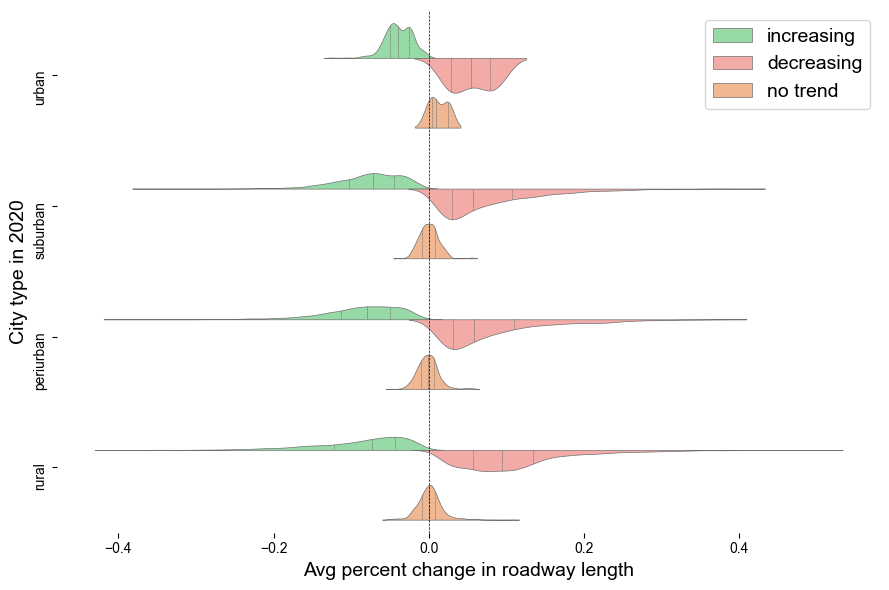

In [87]:
roads_clean['avg_percent_change'] = roads_clean[['percent change from 2020-2040', 'percent change from 2040-2060', 
                                                 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=1)
fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(ax=ax, data = roads_clean, y= 'city type', x= 'avg_percent_change', hue='future trend from SSP 2', split=True, inner="quart",
               order=['urban', 'suburban', 'periurban', 'rural'], palette = ['#8de5a1','#ff9f9b', '#ffb482'], linewidth=0.5)
ax.axvline(x = 0, linestyle = '--', linewidth = 0.5, color ='black') 
ax.set(frame_on=False)
# sns.set_style("whitegrid", {'axes.grid' : False})
plt.yticks(rotation=90, ha='right')
ax.legend(fontsize=14,)
ax.set_xlabel('Avg percent change in roadway length',fontsize=14)
ax.set_ylabel('City type in 2020',fontsize=14)
sns.set_style("ticks")
fig.tight_layout()
plt.savefig(r"D:\Work\Box Sync\Quantify Infrastructure\Figures\avg_percent_roadway_change.png", transparent=True)
# plt.legend(loc='lower right')
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

In [88]:
building_df_sorted = building_clean_sub[building_clean_sub['CensusPop_20'] > 5000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 
        'sub_per_cap_mass_at_2020', 'sub_per_cap_mass_at_2030',
       'sub_per_cap_mass_at_2040', 'sub_per_cap_mass_at_2050',
       'sub_per_cap_mass_at_2060', 'sub_per_cap_mass_at_2070',
       'sub_per_cap_mass_at_2080', 'sub_per_cap_mass_at_2090',
       'sub_per_cap_mass_at_2100']]

# building_df_sorted = building_clean[building_clean['CensusPop_20'] > 500000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 'per_cap_mass_at_2020', 
#                                     'per_cap_mass_at_2030',  'per_cap_mass_at_2040',  'per_cap_mass_at_2050',  'per_cap_mass_at_2060', 
#                                     'per_cap_mass_at_2070',  'per_cap_mass_at_2080',  'per_cap_mass_at_2090',  'per_cap_mass_at_2100',]]

lower_10 = building_df_sorted.head(10).set_index('NAMELSAD') 
upper_10 = building_df_sorted.tail(10).set_index('NAMELSAD') 

df_lineplot = [lower_10.T, upper_10.T]
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(25,7))
fig.suptitle('Per capita added volume at each decade for cities  with population over half million', fontsize= 14)
axes[0].set_title('Bottom 10 cities', fontsize= 14)
axes[1].set_title('Top 10 cities', fontsize= 14)
for ax , df in zip(axes, df_lineplot):
    sns.lineplot(ax= ax, data=df, legend = False)
    # sns.move_legend(ax, loc = 2, bbox_to_anchor=(1, 1))
    ax.axhline(y=0, color = 'black', alpha = 1,linestyle= '--')
    ax.set_xticks(range(len(df)), ['2020', '2030','2040','2050','2060','2070','2080','2090', '2100']) #,rotation = 30)
    ax.tick_params(labelsize= 14)
    ax.legend(frameon=False)
plt.rc('legend',fontsize=14) 
plt.subplots_adjust(wspace=0.1, hspace=0.1)

NameError: name 'building_clean_sub' is not defined

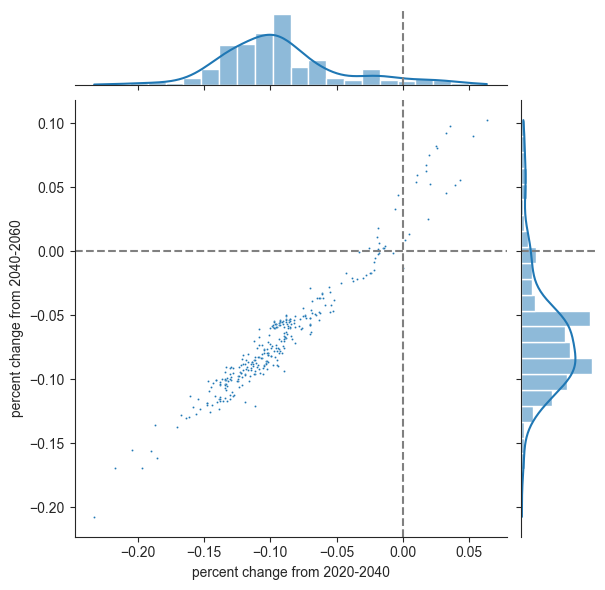

In [ ]:
g = sns.JointGrid(data=roads_clean[roads_clean['city type'] == 'urban'], x='percent change from 2020-2040', y = 'percent change from 2040-2060',)
g.plot_joint(sns.scatterplot, s=2, )
g.plot_marginals(sns.histplot, kde=True)
g.refline(x=0, y=0)

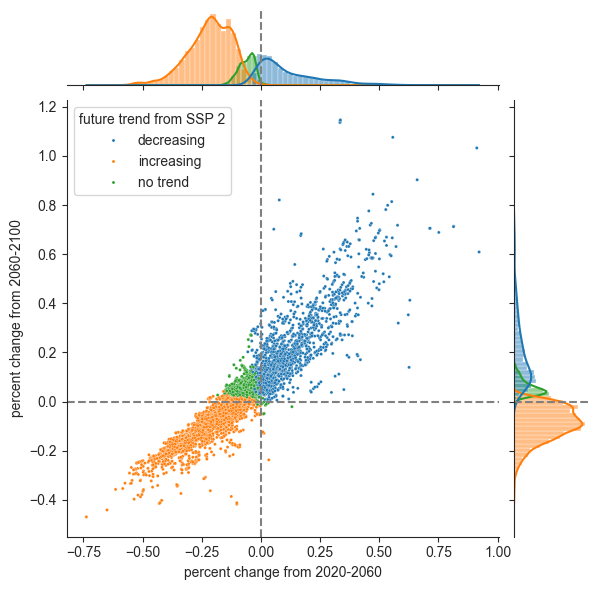

In [ ]:
plt.rc('legend',fontsize=10) 
g = sns.JointGrid(data=roads_df[roads_df['city type'] == 'suburban'], x='percent change from 2020-2060', y = 'percent change from 2060-2100',
                  marginal_ticks=False, hue="future trend from SSP 2")
g.plot_joint(sns.scatterplot, s=5, )
g.plot_marginals(sns.histplot, kde=True, linewidth =0.2)
g.refline(x=0, y=0)


In [ ]:
# print(sns.color_palette("pastel").as_hex())

In [ ]:
roads_df[roads_df['percent change from 2060-2100'] >= roads_df['percent change from 2020-2060']][['NAMELSAD', 'percent change from 2020-2060', 'percent change from 2060-2100',]].sort_values(by = 'percent change from 2060-2100')

,NAMELSAD,percent change from 2020-2060,percent change from 2060-2100
19843,Tioga city,-0.773815,-0.483656
20146,Trenton CDP,-0.772829,-0.483423
19842,Ray city,-0.767384,-0.481477
20130,Long Creek CDP,-0.763794,-0.480420
20131,McGregor CDP,-0.756475,-0.477500
...,...,...,...
21092,Berlin CDP,0.110582,1.306195
21040,Killbuck village,0.111209,1.306962
20859,Nashville village,0.116017,1.309859
26389,Floydada city,0.588480,1.440580


In [ ]:
roads_df[roads_df['percent change from 2060-2100'] < roads_df['percent change from 2020-2060']][['NAMELSAD', 'percent change from 2020-2060', 'percent change from 2060-2100',]].sort_values(by = 'percent change from 2060-2100')

,NAMELSAD,percent change from 2020-2060,percent change from 2060-2100
25120,Cavour town,-0.421449,-0.488119
25504,Riverside Colony CDP,-0.421959,-0.487926
25500,Provo CDP,0.121220,-0.477903
25119,Broadland town,-0.424955,-0.476169
25369,Martin city,-0.255826,-0.470236
...,...,...,...
17663,Watrous CDP,1.062500,1.000000
17482,Mora CDP,1.048689,1.022727
9477,Rolla city,1.219653,1.162500
9476,Elkhart city,1.234320,1.183463


#### Unused plots

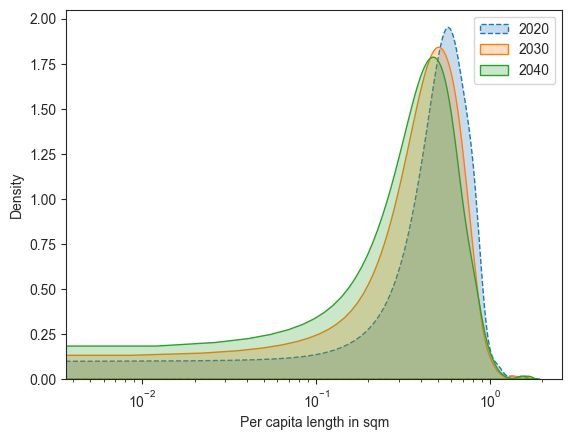

In [ ]:
df_plot_city = roads_clean[roads_clean['city type'] == 'urban']

fig, ax = plt.subplots()
sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2020']), fill=True, ax=ax, linestyle="--") 
# sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2030']), fill=True, ax=ax)
# sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2040']), fill=True, ax=ax)
# sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2050']), fill=True, ax=ax)
sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2060']), fill=True, ax=ax)
# sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2070']), fill=True, ax=ax)
# sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2080']), fill=True, ax=ax)
# sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2090']), fill=True, ax=ax)
sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2100']), fill=True, ax=ax)
fig.canvas.draw()
locs, labels = plt.xticks()
plt.xscale('log')
plt.xlabel('Per capita length in sqm')
plt.legend(labels=['2020', '2030', '2040', '2050', '2060', '2070', '2080', '2090', '2100'])
# # Or for scientific notation:
# ax.set(xticklabels=["$10^" + i.get_text() + "$" for i in labels])
plt.show()

<Axes: xlabel='value', ylabel='Density'>

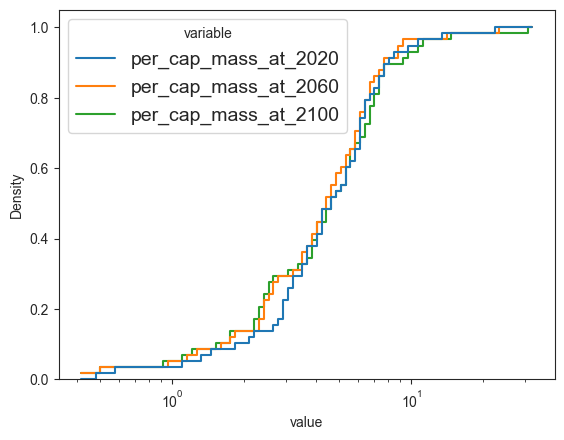

In [ ]:
# make dataframe
data = roads_clean[(roads_clean['city type'] == 'urban') & (roads_clean['label'].str.contains('depopulating'))]
df = data[['per_cap_mass_at_2020', 'per_cap_mass_at_2060', 'per_cap_mass_at_2100']]

# plot melted dataframe in a single command
sns.histplot(df.melt(), x='value', hue='variable', log_scale=True, bins=80, binwidth =0.02, shrink=.8, fill=False,
             cumulative=True, stat="density", common_norm=False,element="step",)